# Data Exploration for Equality Files

This notebook explores the three CSV files to understand their structure and identify potential issues for merging.

Files:
- Equality Hip and Knee Replacement 1617.csv
- Equality 1718.csv
- Equality 1819.csv

In this set of data, for a certain group of patient how the pain is distributed.

In [2]:
import pandas as pd
import numpy as np

In [3]:
# Define file paths
file_1617 = '../external/Equality Hip and Knee Replacement 1617.csv'
file_1718 = '../external/Equality 1718.csv'
file_1819 = '../external/Equality 1819.csv'

# Load the dataframes
df_1617 = pd.read_csv(file_1617, sep=';')
df_1718 = pd.read_csv(file_1718)
df_1819 = pd.read_csv(file_1819)

In [7]:
# Check shapes
print("Shape of 1617:", df_1617.shape)
print("Shape of 1718:", df_1718.shape)
print("Shape of 1819:", df_1819.shape)

# Check columns
print("Columns of 1617:", list(df_1617.columns))
print("Columns of 1718:", list(df_1718.columns))
print("Columns of 1819:", list(df_1819.columns))

# Sample data
print("Head of 1617:")
print(df_1617.head())
print("\nHead of 1718:")
print(df_1718.head())
print("\nHead of 1819:")
print(df_1819.head())

Shape of 1617: (732, 26)
Shape of 1718: (732, 26)
Shape of 1819: (732, 26)
Columns of 1617: ['Dimension', 'Value', 'Procedure', 'Measure', 'Pre-Op Q Mean', 'Pre-Op Q 5%', 'Pre-Op Q 1st Quartile', 'Pre-Op Q Median', 'Pre-Op Q 3rd Quartile', 'Pre-Op Q 95%', 'Post-Op Q Mean', 'Post-Op Q 5%', 'Post-Op Q 1st Quartile', 'Post-Op Q Median', 'Post-Op Q 3rd Quartile', 'Post-Op Q 95%', 'Heath Gain Mean', 'Heath Gain 5%', 'Heath Gain 1st Quartile', 'Heath Gain Median', 'Heath Gain 3rd Quartile', 'Heath Gain 95%', 'Improved', 'Unchanged', 'Worsened', 'Total']
Columns of 1718: ['Dimension', 'Value', 'Procedure', 'Measure', 'Pre-Op Q Mean', 'Pre-Op Q 5%', 'Pre-Op Q 1st Quartile', 'Pre-Op Q Median', 'Pre-Op Q 3rd Quartile', 'Pre-Op Q 95%', 'Post-Op Q Mean', 'Post-Op Q 5%', 'Post-Op Q 1st Quartile', 'Post-Op Q Median', 'Post-Op Q 3rd Quartile', 'Post-Op Q 95%', 'Heath Gain Mean', 'Heath Gain 5%', 'Heath Gain 1st Quartile', 'Heath Gain Median', 'Heath Gain 3rd Quartile', 'Heath Gain 95%', 'Improved', '

In [4]:
# Check for missing values
print("Missing values in 1617:")
print(df_1617.isnull().sum())
print("\nMissing values in 1718:")
print(df_1718.isnull().sum())
print("\nMissing values in 1819:")
print(df_1819.isnull().sum())

# Convert numeric columns if needed
numeric_cols = ['Pre-Op Q Mean', 'Pre-Op Q 5%', 'Pre-Op Q 1st Quartile', 'Pre-Op Q Median', 'Pre-Op Q 3rd Quartile', 'Pre-Op Q 95%', 'Post-Op Q Mean', 'Post-Op Q 5%', 'Post-Op Q 1st Quartile', 'Post-Op Q Median', 'Post-Op Q 3rd Quartile', 'Post-Op Q 95%', 'Heath Gain Mean', 'Heath Gain 5%', 'Heath Gain 1st Quartile', 'Heath Gain Median', 'Heath Gain 3rd Quartile', 'Heath Gain 95%', 'Improved', 'Unchanged', 'Worsened', 'Total']

for df in [df_1617, df_1718, df_1819]:
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

Missing values in 1617:
Dimension;Value;Procedure;Measure;Pre-Op Q Mean;Pre-Op Q 5%;Pre-Op Q 1st Quartile;Pre-Op Q Median;Pre-Op Q 3rd Quartile;Pre-Op Q 95%;Post-Op Q Mean;Post-Op Q 5%;Post-Op Q 1st Quartile;Post-Op Q Median;Post-Op Q 3rd Quartile;Post-Op Q 95%;Heath Gain Mean;Heath Gain 5%;Heath Gain 1st Quartile;Heath Gain Median;Heath Gain 3rd Quartile;Heath Gain 95%;Improved;Unchanged;Worsened;Total    0
dtype: int64

Missing values in 1718:
Dimension                    0
Value                        0
Procedure                    0
Measure                      0
Pre-Op Q Mean              234
Pre-Op Q 5%                234
Pre-Op Q 1st Quartile      234
Pre-Op Q Median            234
Pre-Op Q 3rd Quartile      234
Pre-Op Q 95%               234
Post-Op Q Mean             234
Post-Op Q 5%               234
Post-Op Q 1st Quartile     234
Post-Op Q Median           234
Post-Op Q 3rd Quartile     234
Post-Op Q 95%              234
Heath Gain Mean            234
Heath Gain 5%          

In [8]:
# Health gains are already calculated in the data as 'Heath Gain Mean' etc.
# Verify by checking a sample
print("Sample health gain calculation:")
sample = df_1718[['Pre-Op Q Mean', 'Post-Op Q Mean', 'Heath Gain Mean']].head()
print(sample)
# Note: Heath Gain = Post-Op - Pre-Op for some measures

Sample health gain calculation:
   Pre-Op Q Mean  Post-Op Q Mean  Heath Gain Mean
0         63.311          77.310           14.000
1          0.340           0.799            0.458
2         17.601          39.813           22.212
3         66.990          75.148            8.157
4          0.414           0.751            0.336


In [4]:
# Add year column
df_1617['Year'] = '2016-17'
df_1718['Year'] = '2017-18'
df_1819['Year'] = '2018-19'

# Concatenate
merged_df = pd.concat([df_1617, df_1718, df_1819], ignore_index=True)
print("Merged shape:", merged_df.shape)
print("Merged columns:", list(merged_df.columns))

# Save the merged dataframe
import os
os.makedirs('../merged', exist_ok=True)
merged_df.to_csv('../merged/Equality Hip and Knee Replacement.csv', index=False)
print("Merged data saved to ../merged/Equality Hip and Knee Replacement.csv")

Merged shape: (2196, 27)
Merged columns: ['Dimension', 'Value', 'Procedure', 'Measure', 'Pre-Op Q Mean', 'Pre-Op Q 5%', 'Pre-Op Q 1st Quartile', 'Pre-Op Q Median', 'Pre-Op Q 3rd Quartile', 'Pre-Op Q 95%', 'Post-Op Q Mean', 'Post-Op Q 5%', 'Post-Op Q 1st Quartile', 'Post-Op Q Median', 'Post-Op Q 3rd Quartile', 'Post-Op Q 95%', 'Heath Gain Mean', 'Heath Gain 5%', 'Heath Gain 1st Quartile', 'Heath Gain Median', 'Heath Gain 3rd Quartile', 'Heath Gain 95%', 'Improved', 'Unchanged', 'Worsened', 'Total', 'Year']


PermissionError: [Errno 13] Permission denied: '../merged/Equality Hip and Knee Replacement.csv'

In [10]:
# Group by Dimension, Value, Procedure, Measure and sum outcomes
outcomes_by_dimension = merged_df.groupby(['Dimension', 'Value', 'Procedure', 'Measure'])[['Improved', 'Unchanged', 'Worsened']].sum()
print("Outcomes by dimension:")
print(outcomes_by_dimension.head())

Outcomes by dimension:
                                                      Improved  Unchanged  \
Dimension Value    Procedure        Measure                                 
Age       10 to 14 Hip Replacement  EQ VAS                 0.0        0.0   
                                    EQ-5D Index            0.0        0.0   
                                    Oxford Hip Score       0.0        0.0   
                   Knee Replacement EQ VAS                 0.0        0.0   
                                    EQ-5D Index            0.0        0.0   

                                                      Worsened  
Dimension Value    Procedure        Measure                     
Age       10 to 14 Hip Replacement  EQ VAS                 0.0  
                                    EQ-5D Index            0.0  
                                    Oxford Hip Score       0.0  
                   Knee Replacement EQ VAS                 0.0  
                                    EQ-5D Index

In [11]:
# Statistical summary of metrics
summary = merged_df.groupby(['Dimension', 'Value', 'Procedure', 'Measure']).agg({
    'Pre-Op Q Mean': ['mean', 'median', 'std'],
    'Post-Op Q Mean': ['mean', 'median', 'std'],
    'Heath Gain Mean': ['mean', 'median', 'std'],
    'Improved': 'sum',
    'Unchanged': 'sum',
    'Worsened': 'sum',
    'Total': 'sum'
})
print("Statistical summary:")
print(summary.head())

Statistical summary:
                                                     Pre-Op Q Mean             \
                                                              mean median std   
Dimension Value    Procedure        Measure                                     
Age       10 to 14 Hip Replacement  EQ VAS                     NaN    NaN NaN   
                                    EQ-5D Index                NaN    NaN NaN   
                                    Oxford Hip Score           NaN    NaN NaN   
                   Knee Replacement EQ VAS                     NaN    NaN NaN   
                                    EQ-5D Index                NaN    NaN NaN   

                                                     Post-Op Q Mean         \
                                                               mean median   
Dimension Value    Procedure        Measure                                  
Age       10 to 14 Hip Replacement  EQ VAS                      NaN    NaN   
                  

In [5]:
# Fill missing values in all columns except specified with the average for the same 'Value' group
exclude_cols = ['Dimension', 'Value', 'Procedure', 'Measure', 'Year']
for col in merged_df.columns:
    if col not in exclude_cols and merged_df[col].dtype in ['float64', 'int64']:
        merged_df[col] = merged_df.groupby('Value')[col].transform(lambda x: x.fillna(x.mean()))

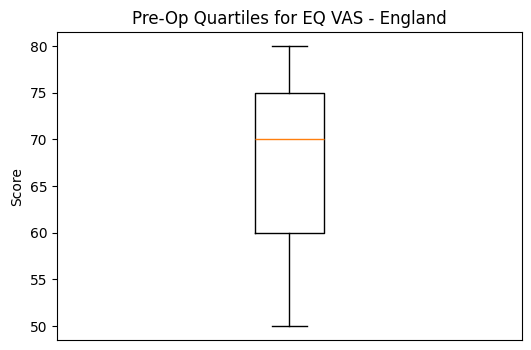

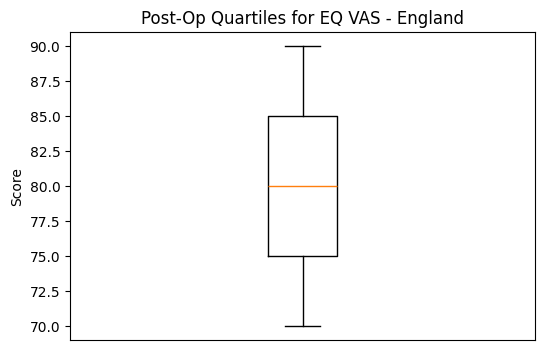

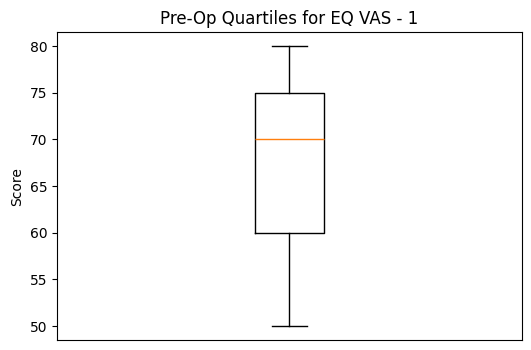

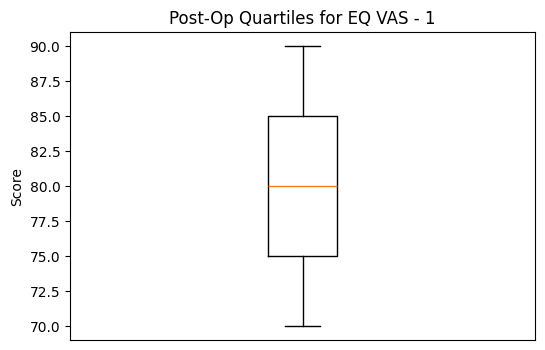

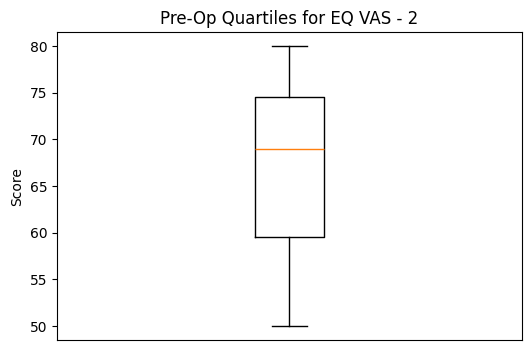

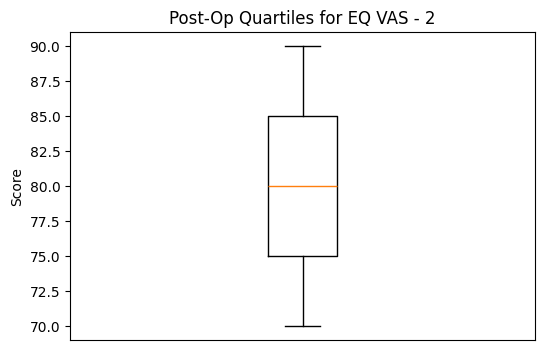

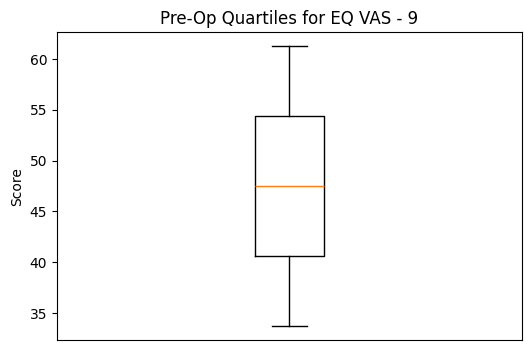

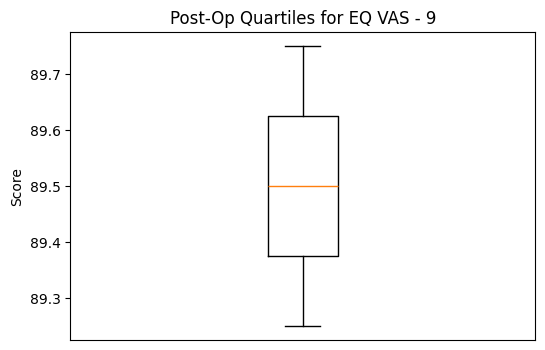

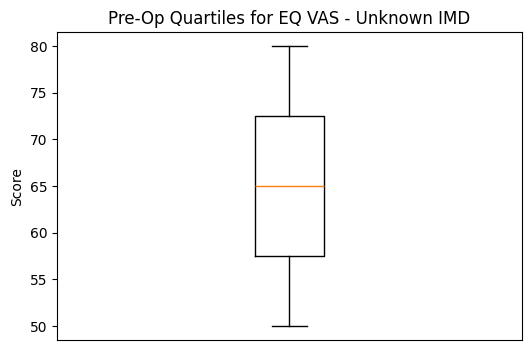

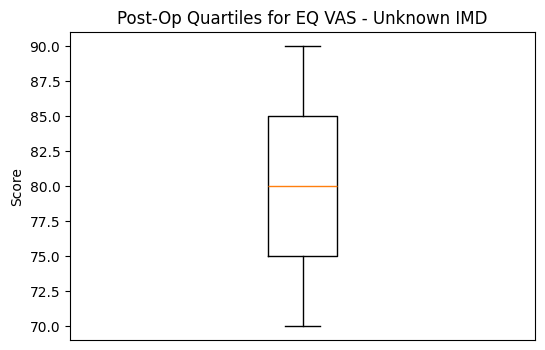

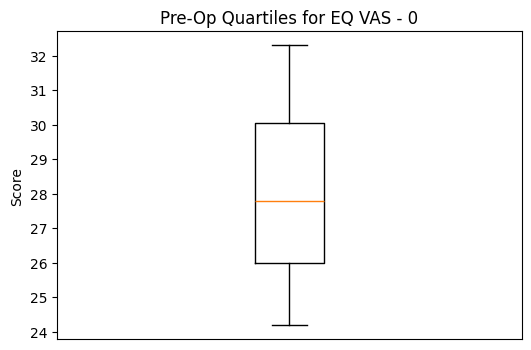

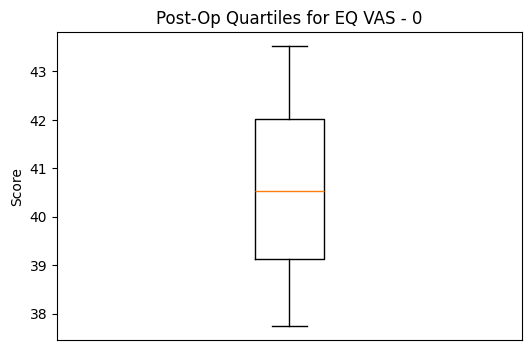

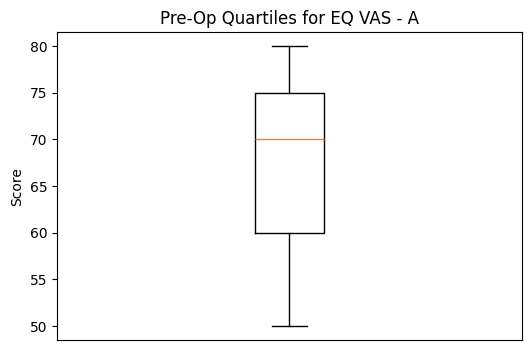

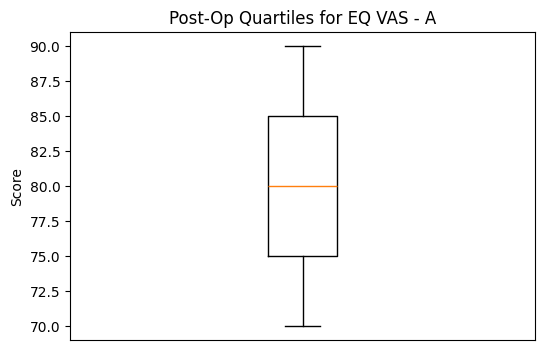

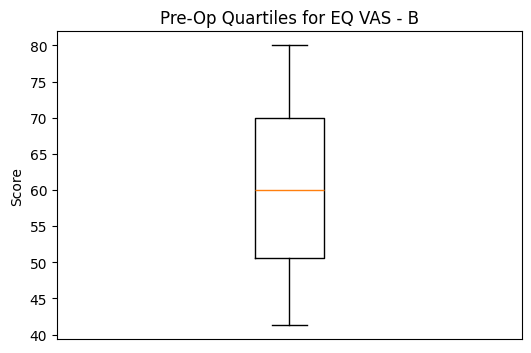

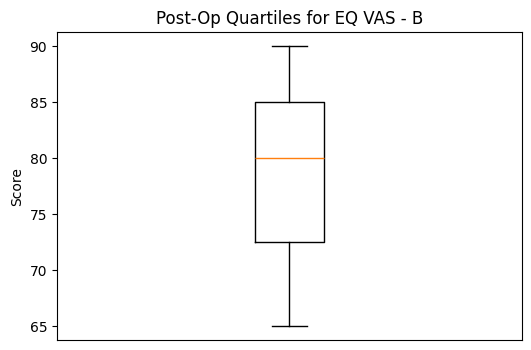

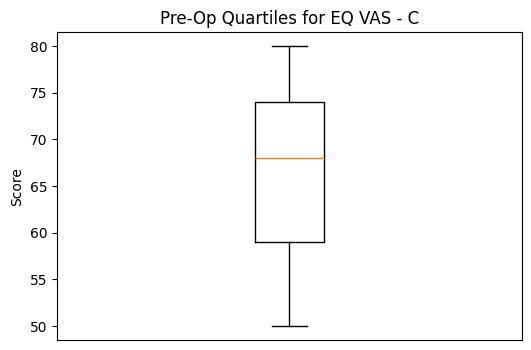

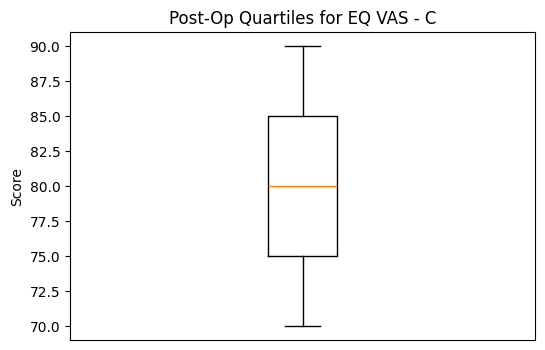

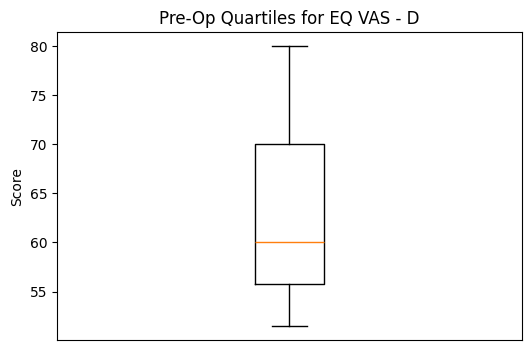

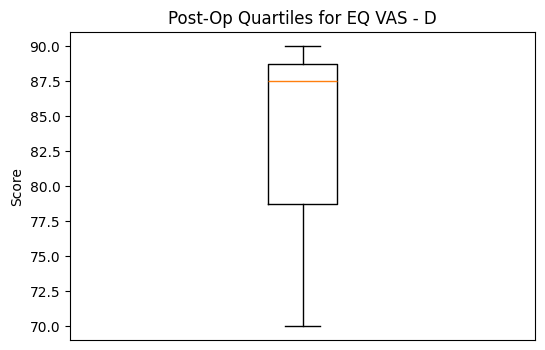

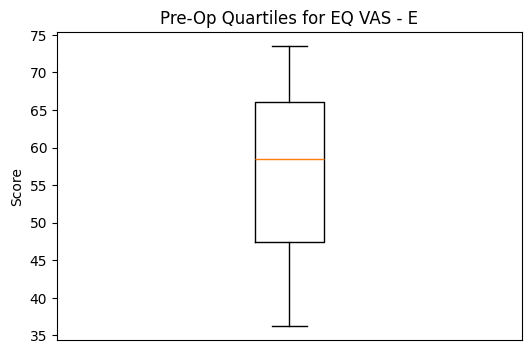

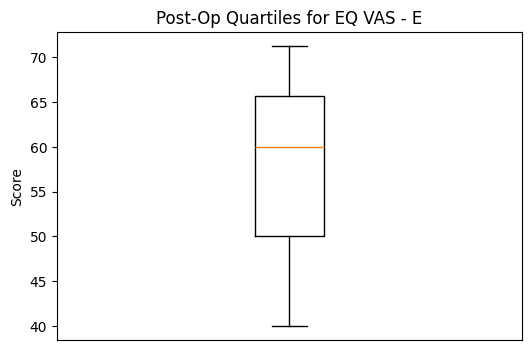

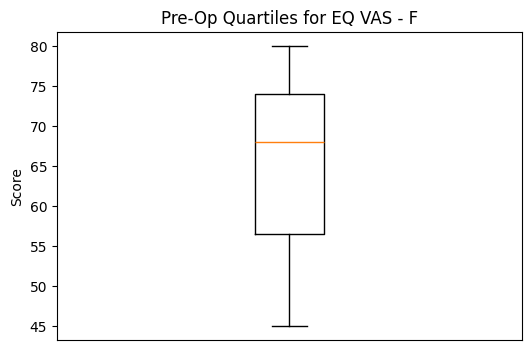

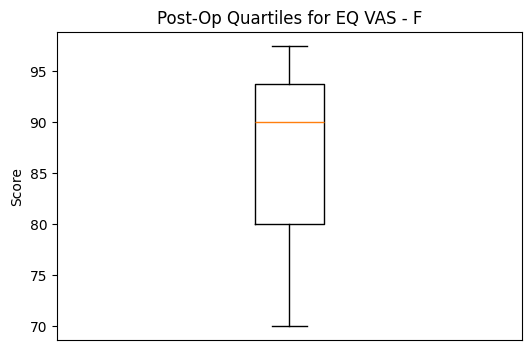

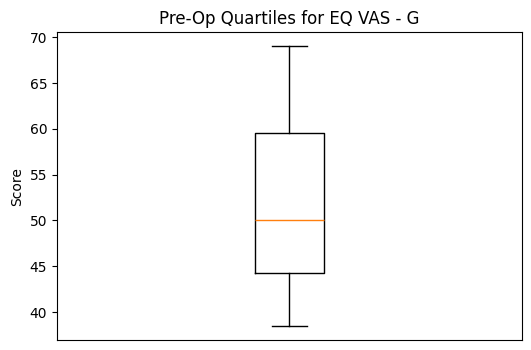

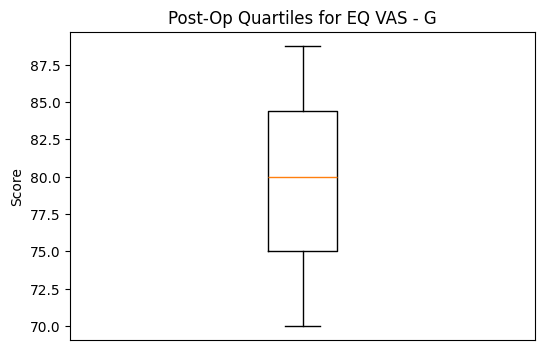

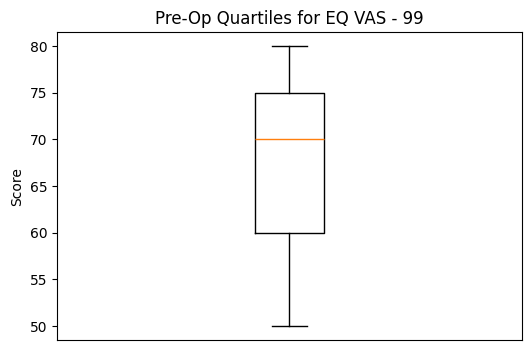

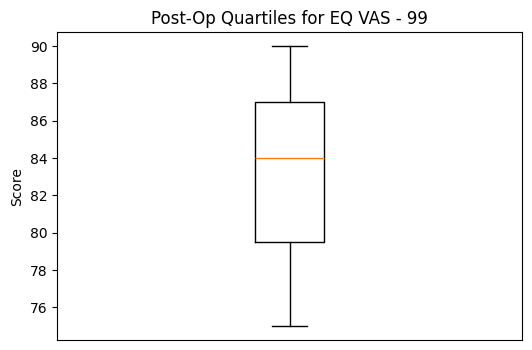

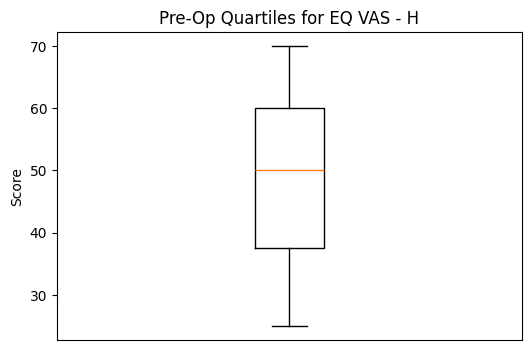

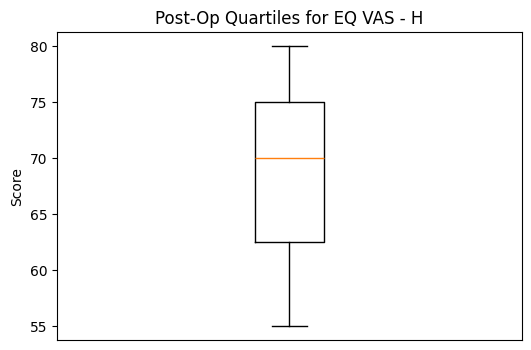

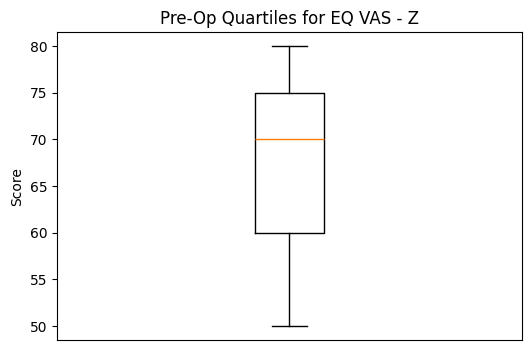

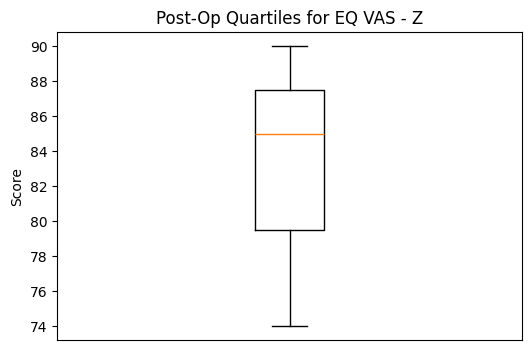

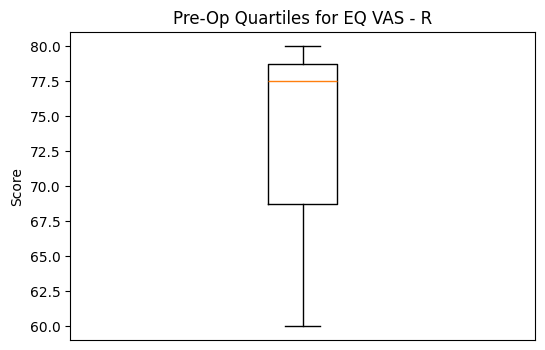

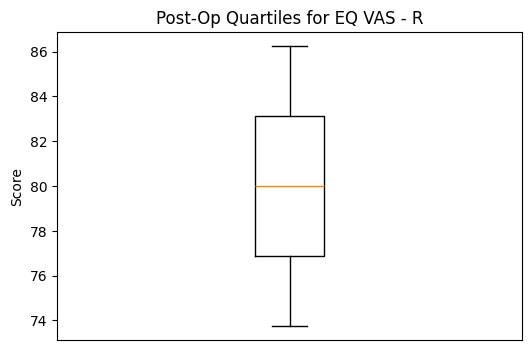

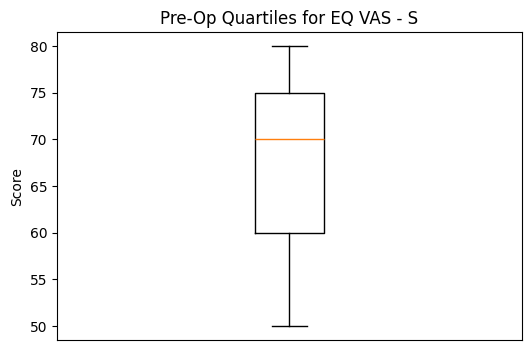

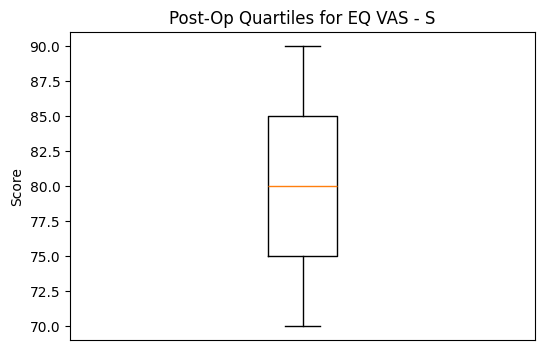

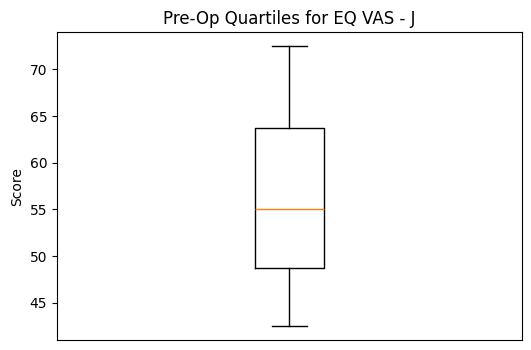

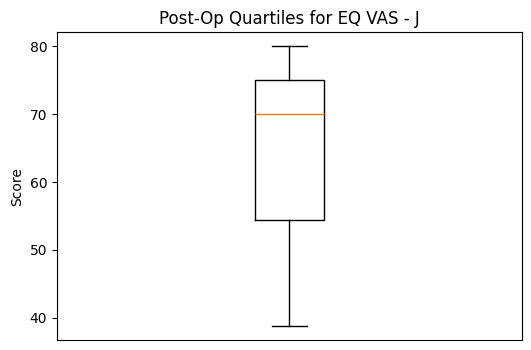

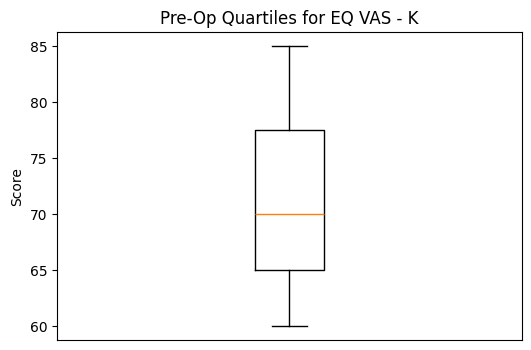

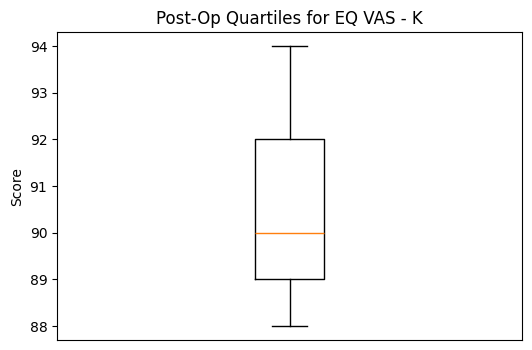

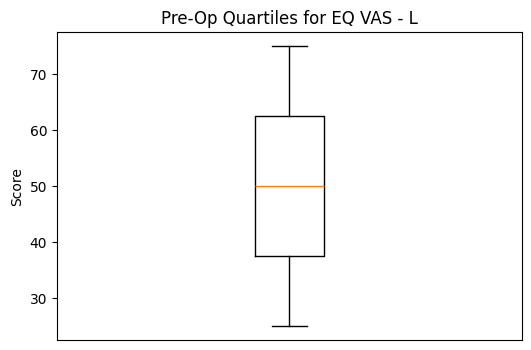

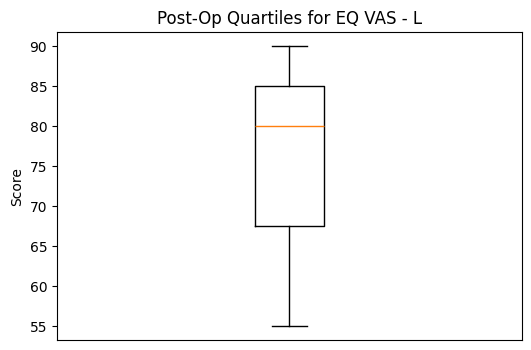

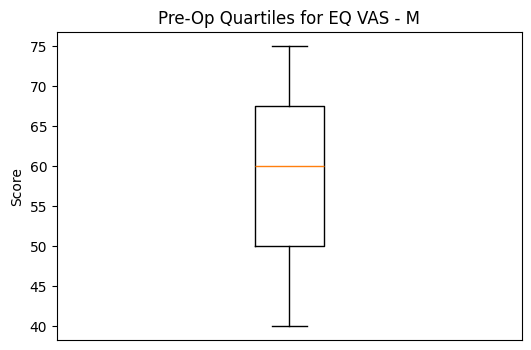

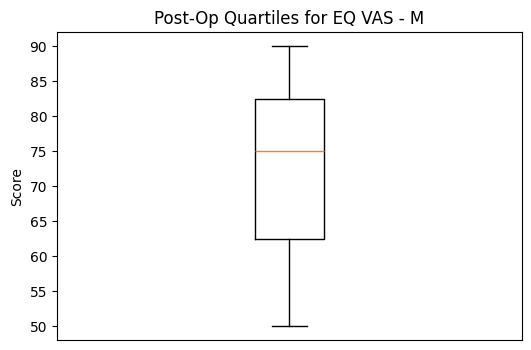

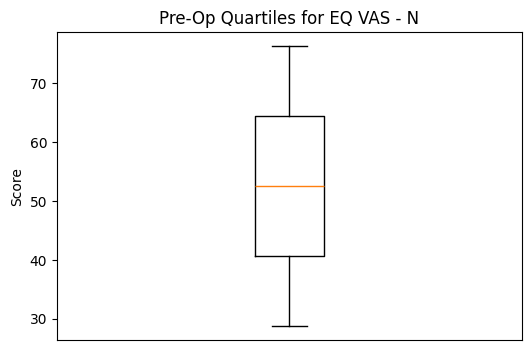

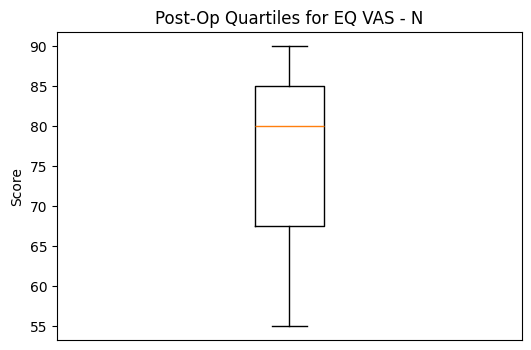

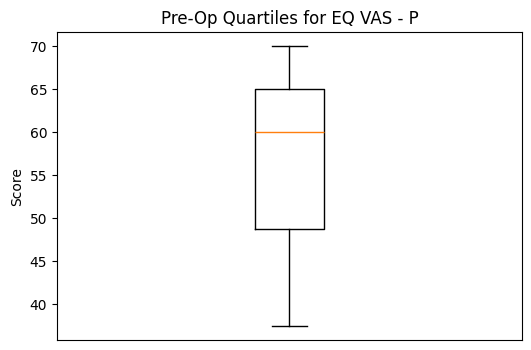

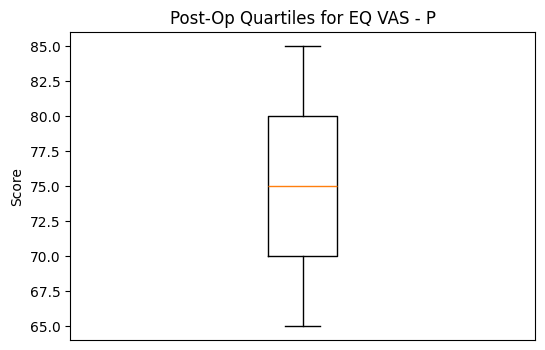

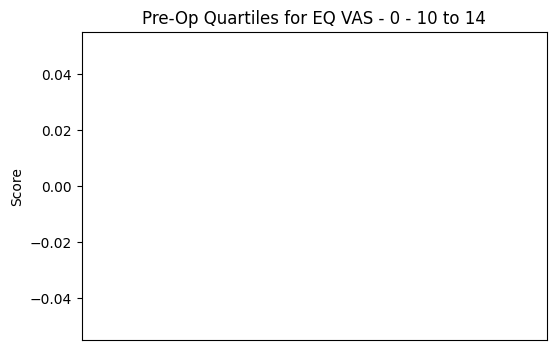

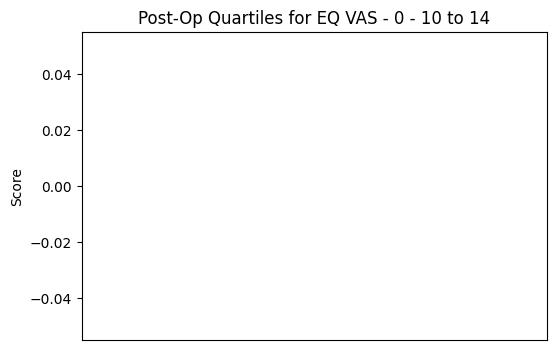

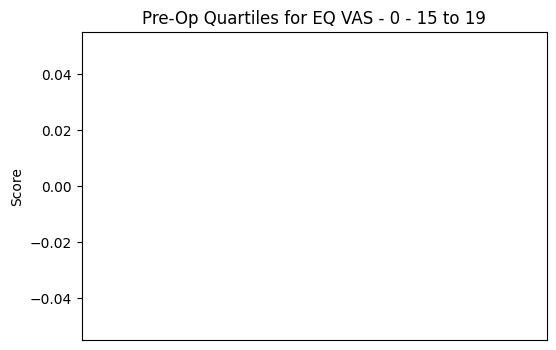

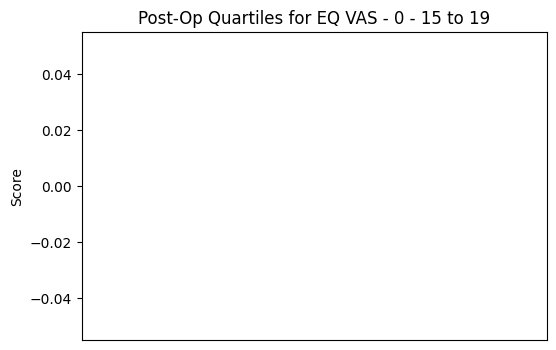

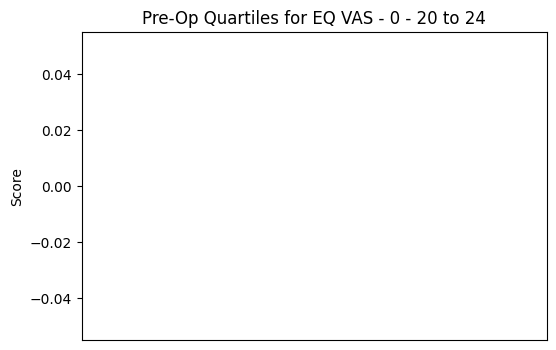

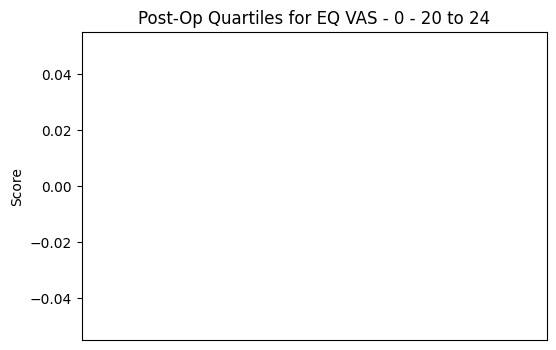

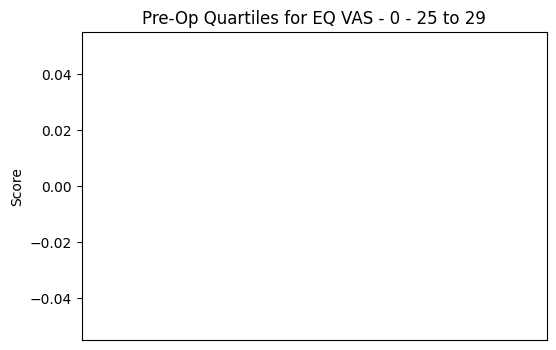

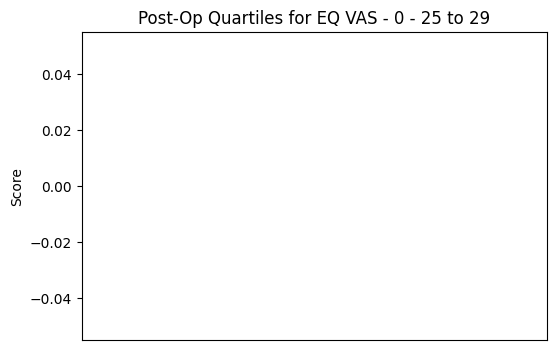

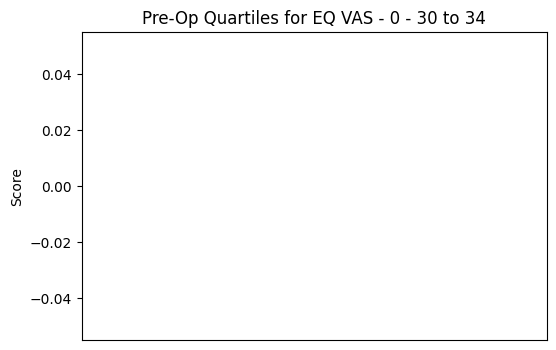

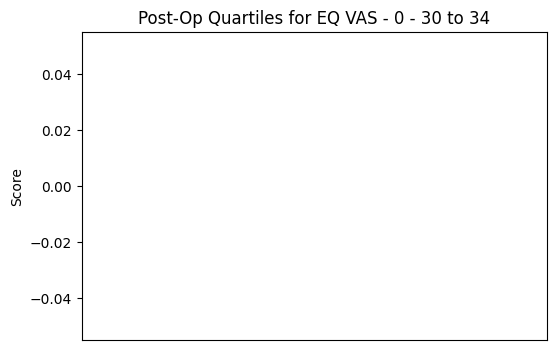

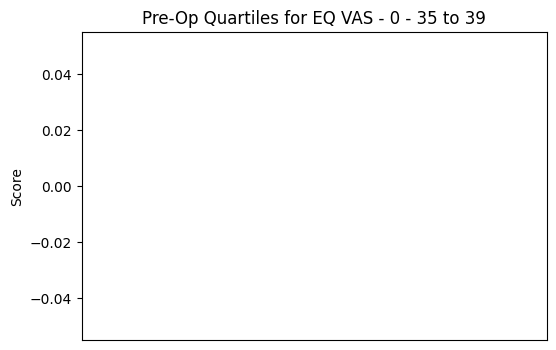

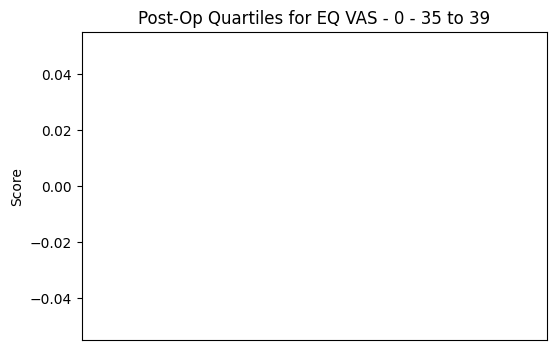

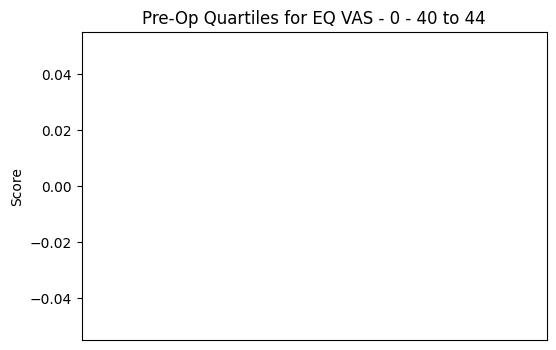

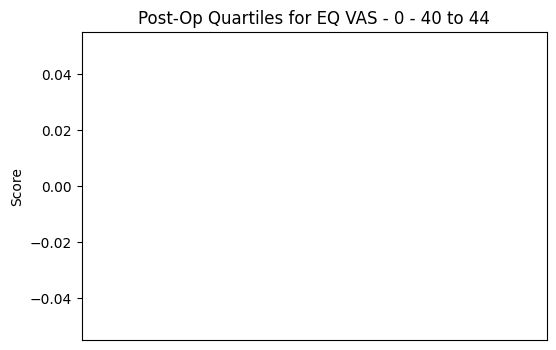

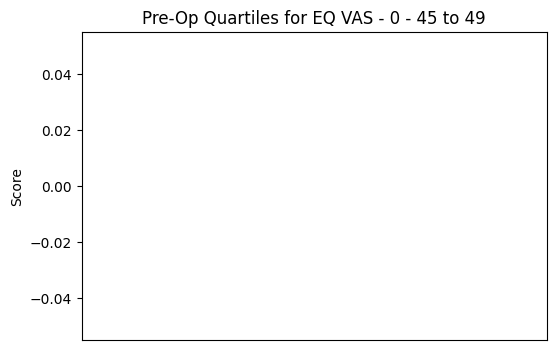

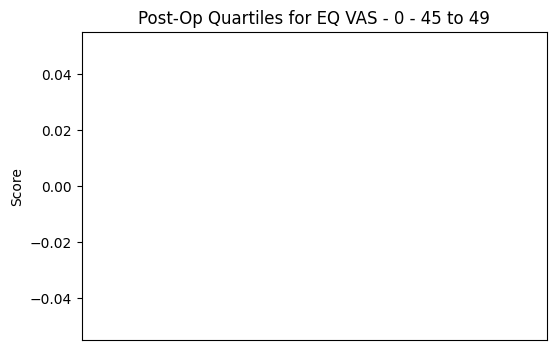

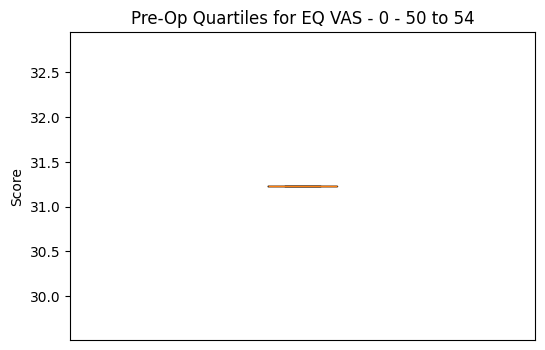

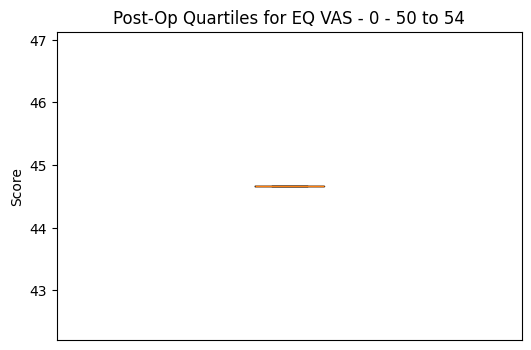

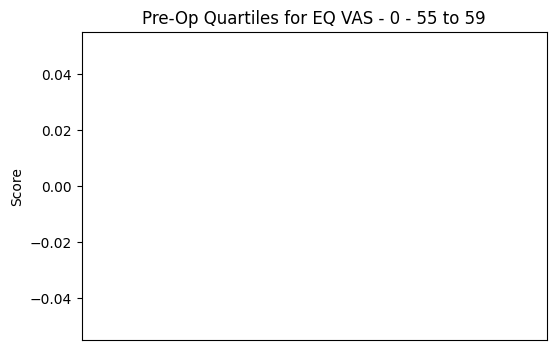

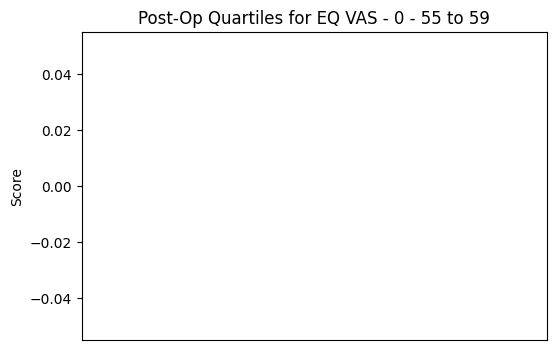

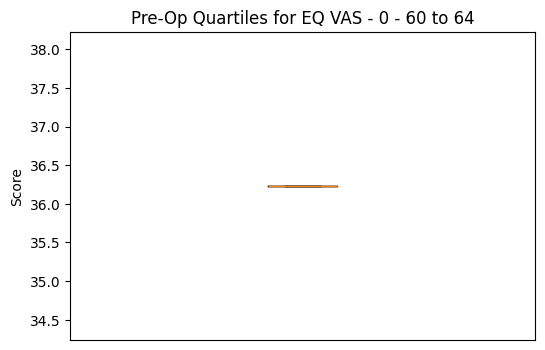

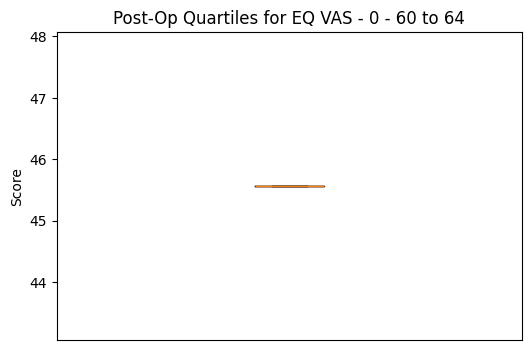

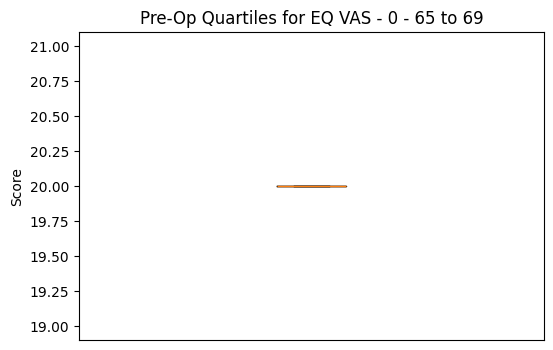

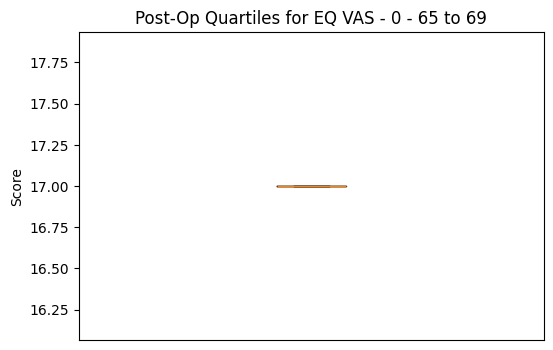

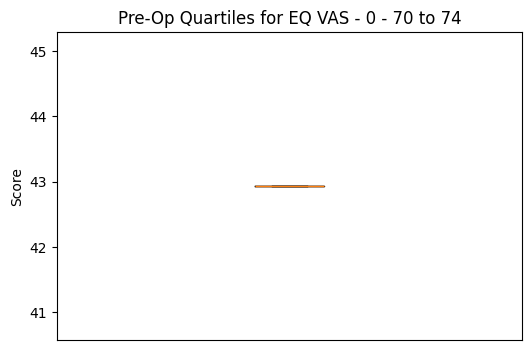

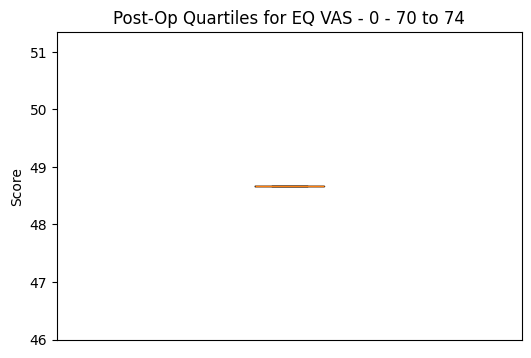

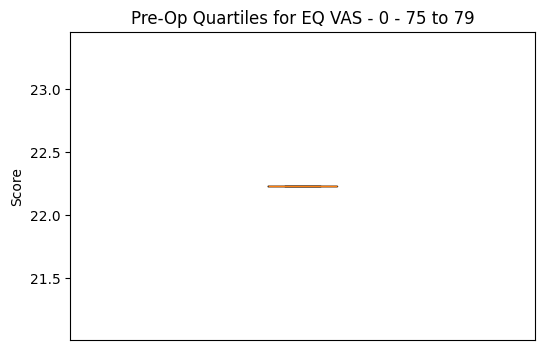

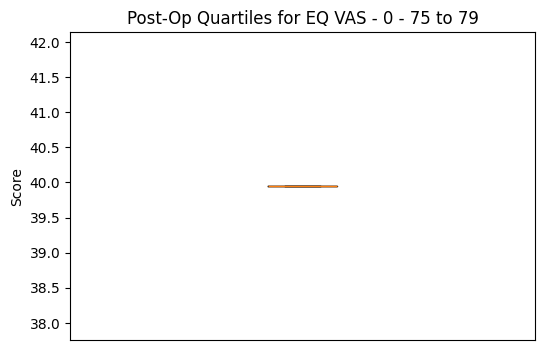

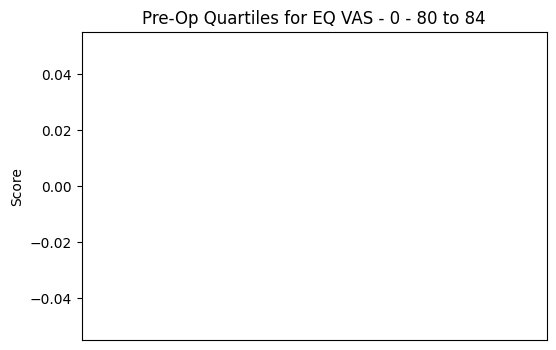

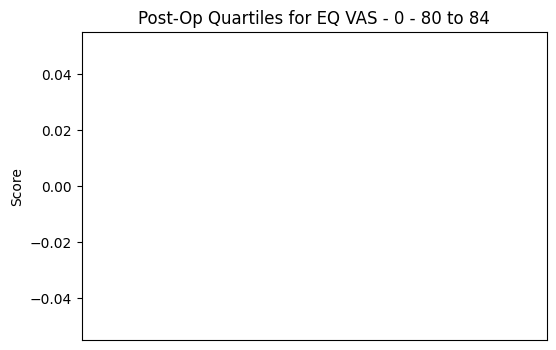

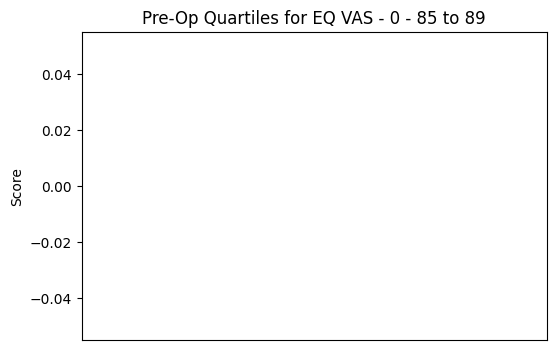

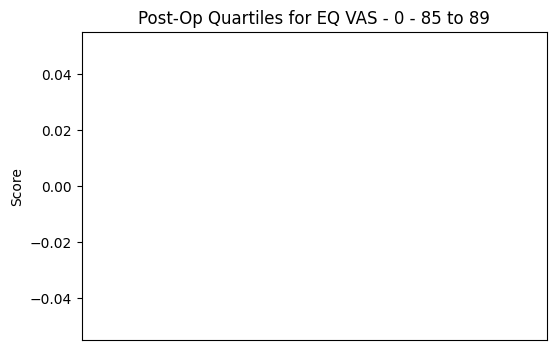

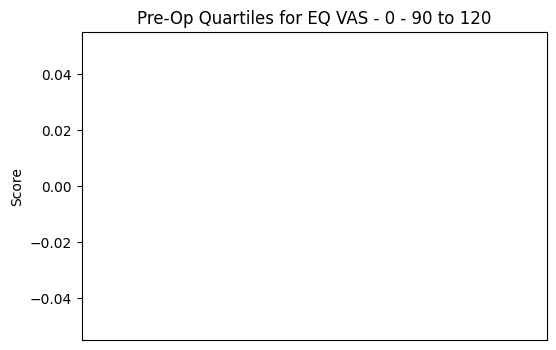

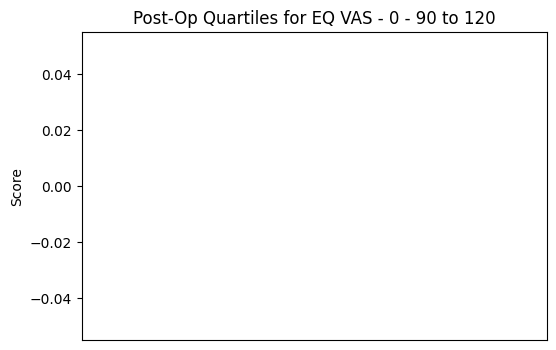

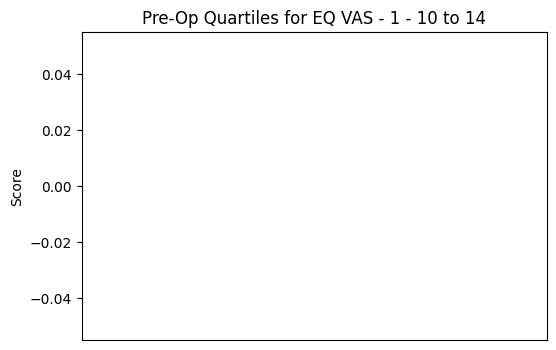

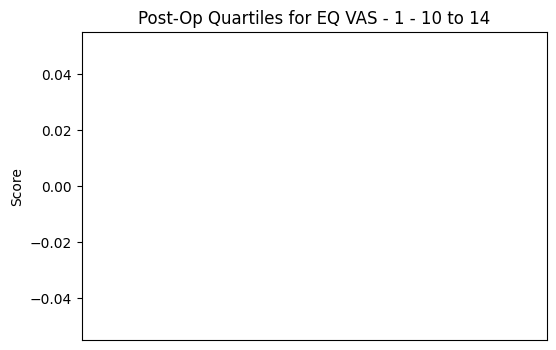

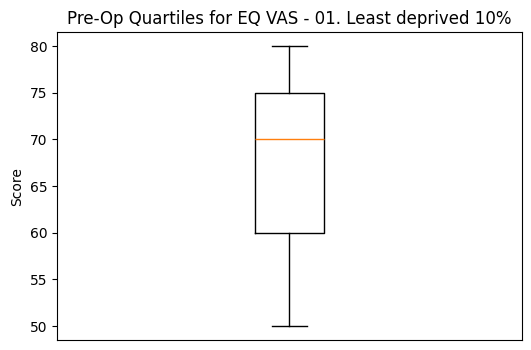

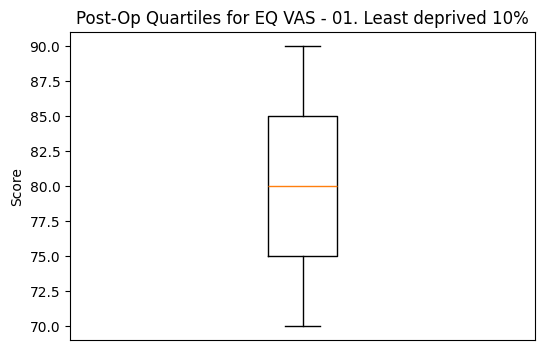

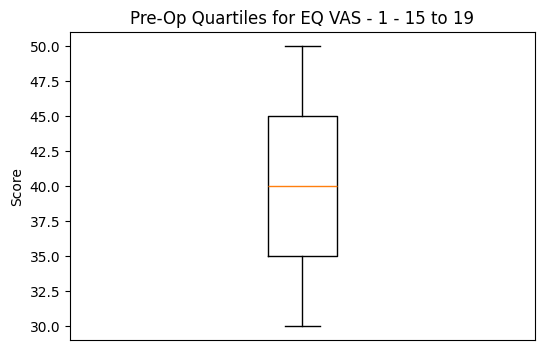

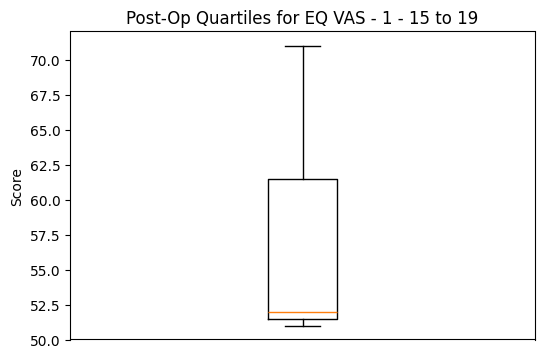

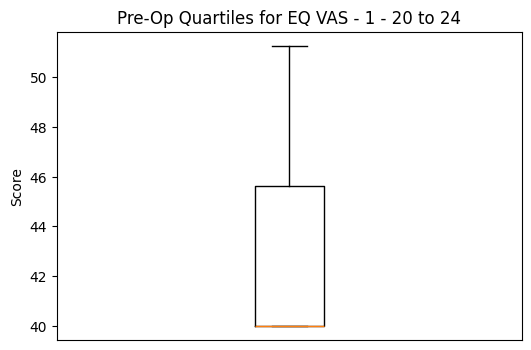

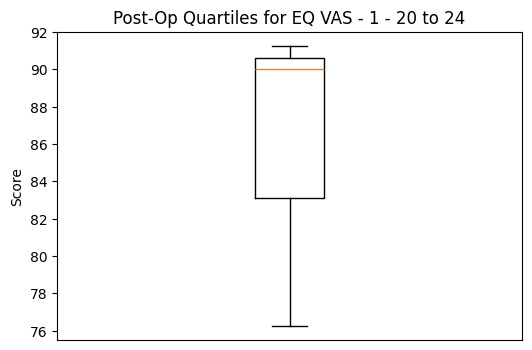

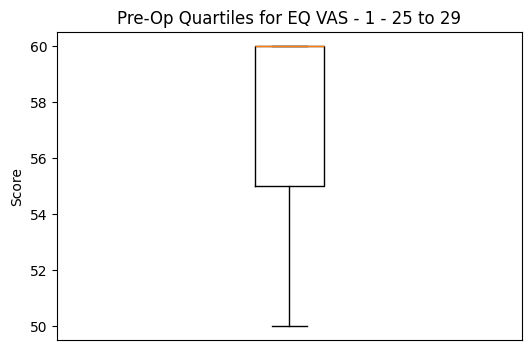

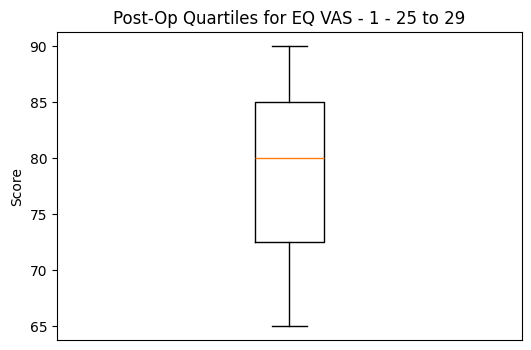

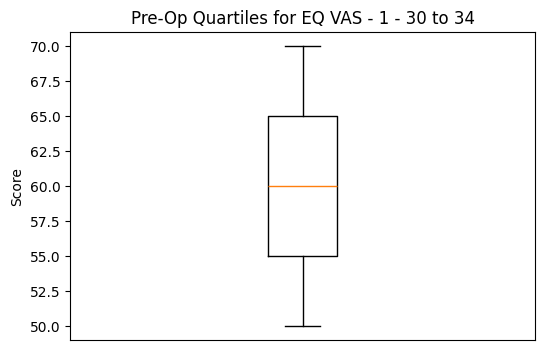

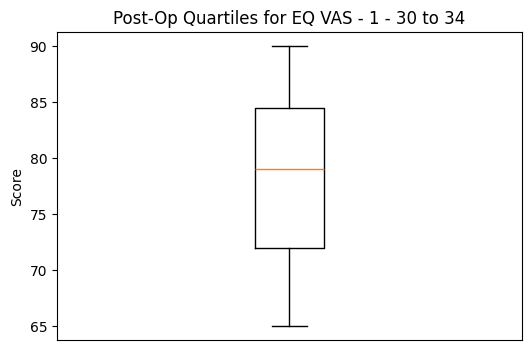

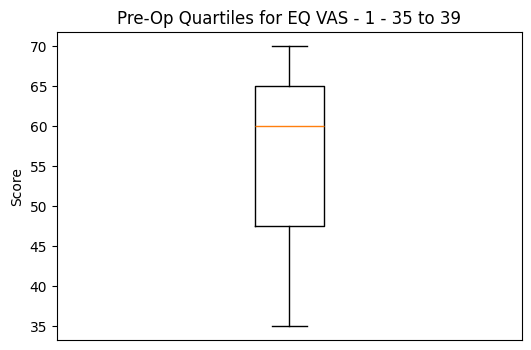

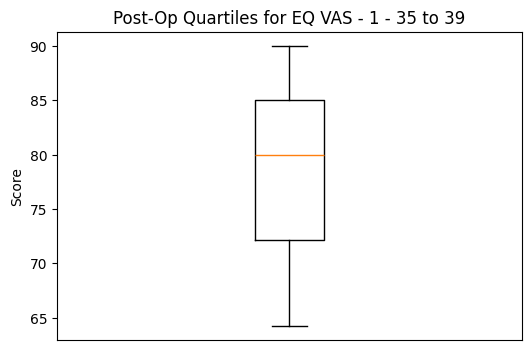

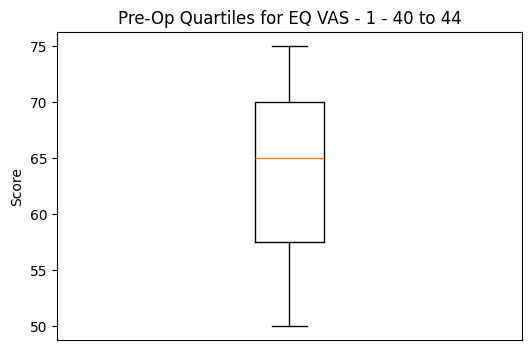

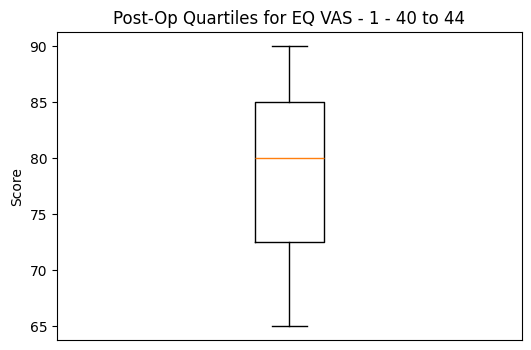

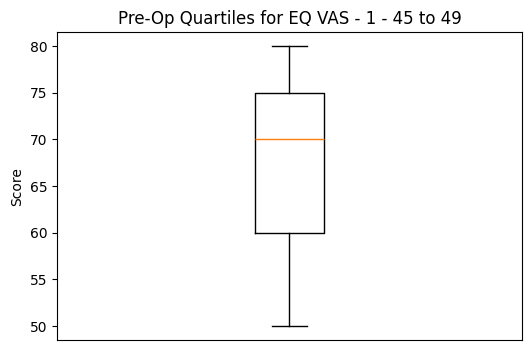

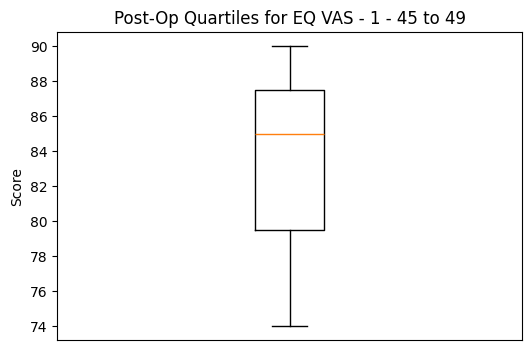

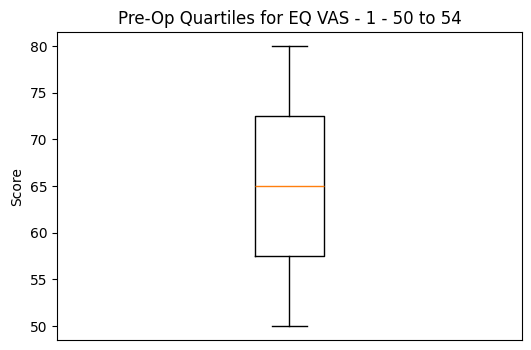

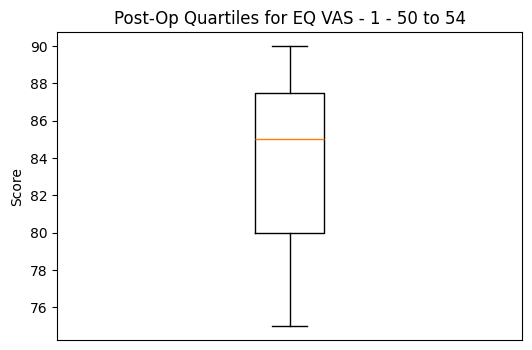

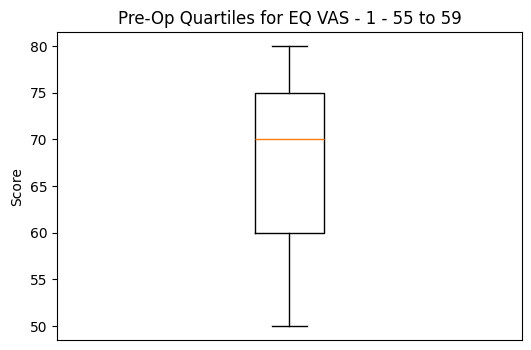

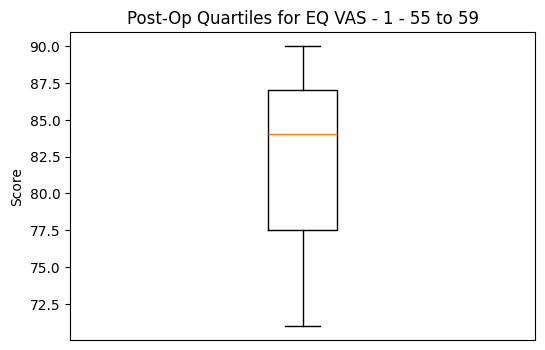

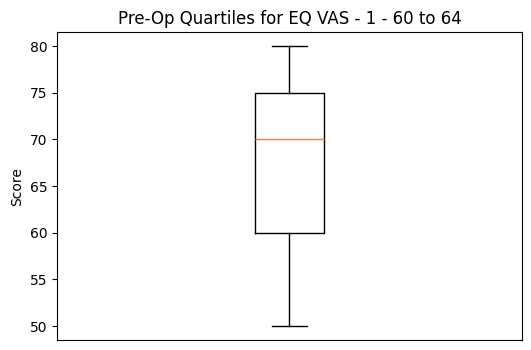

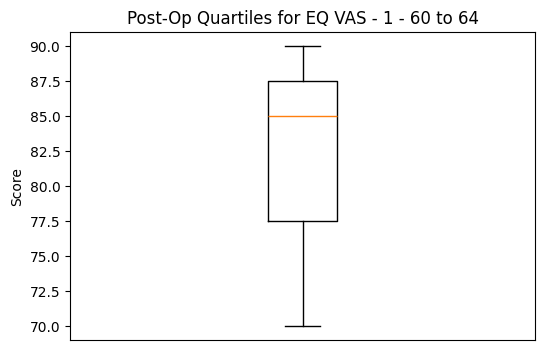

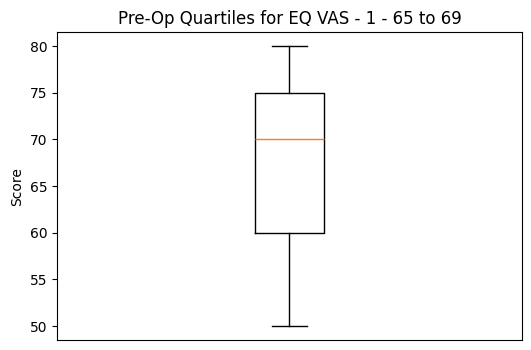

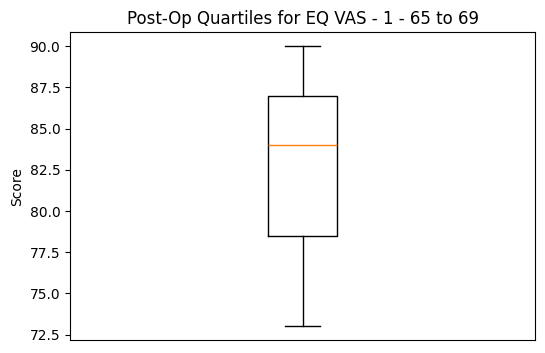

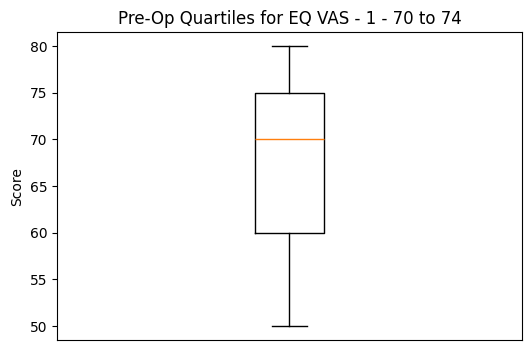

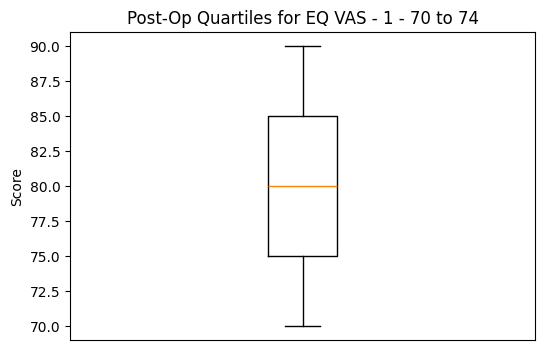

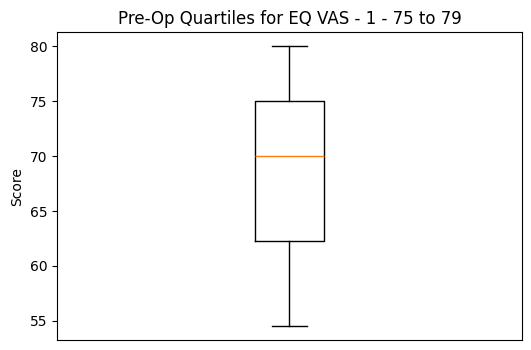

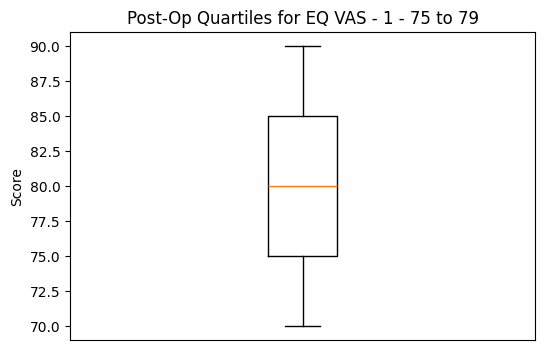

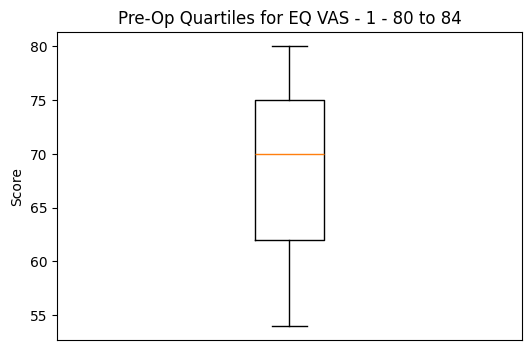

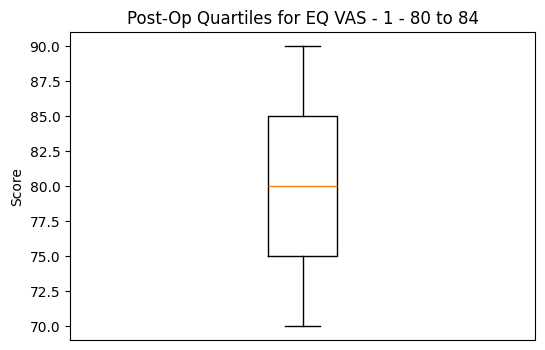

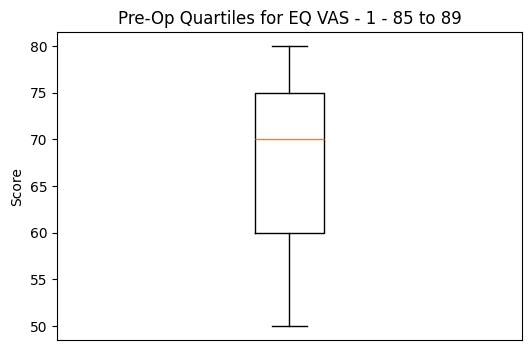

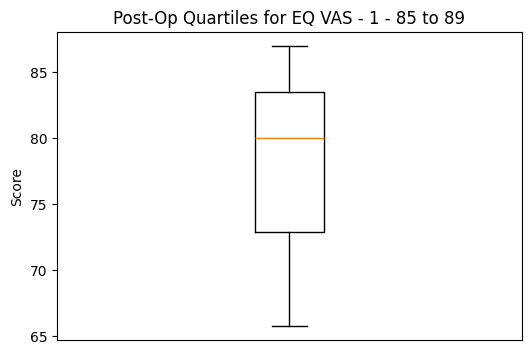

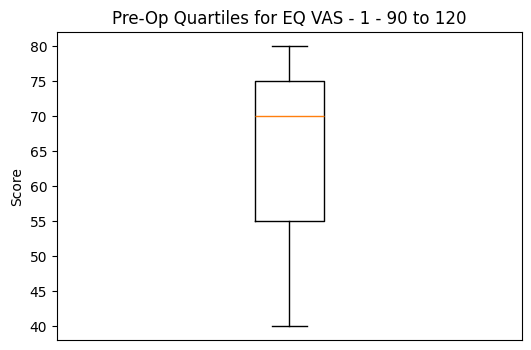

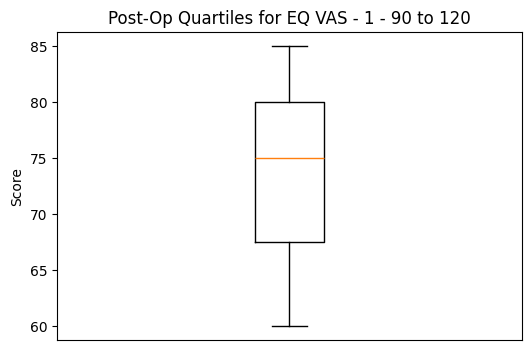

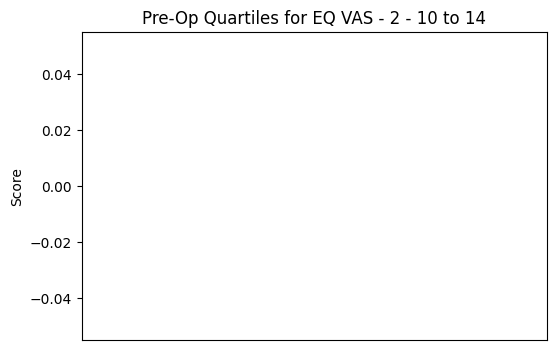

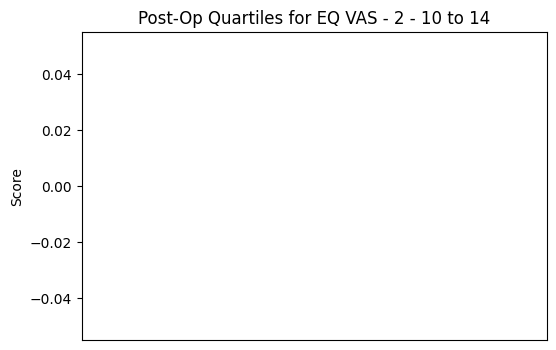

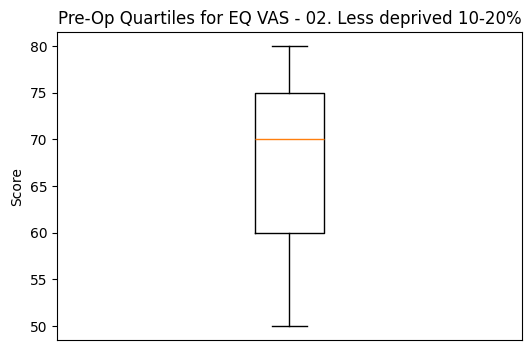

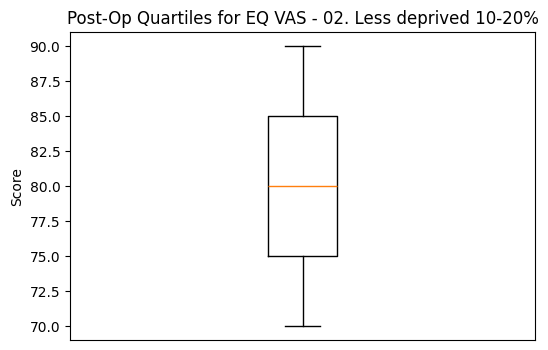

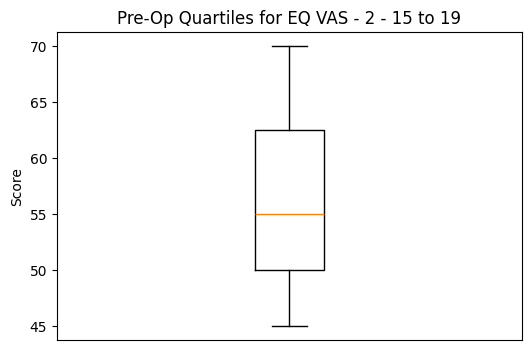

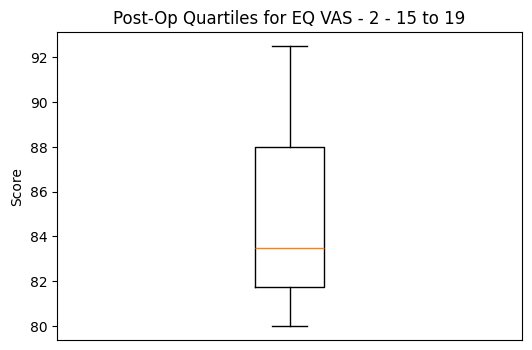

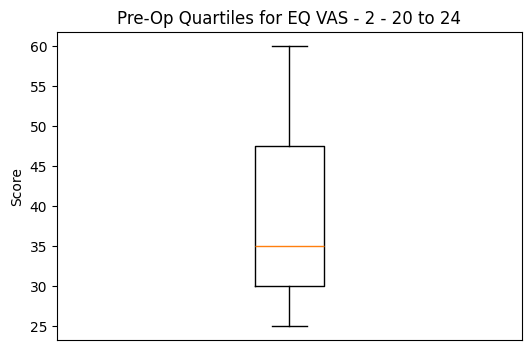

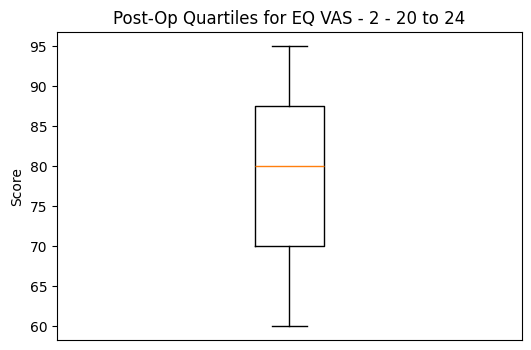

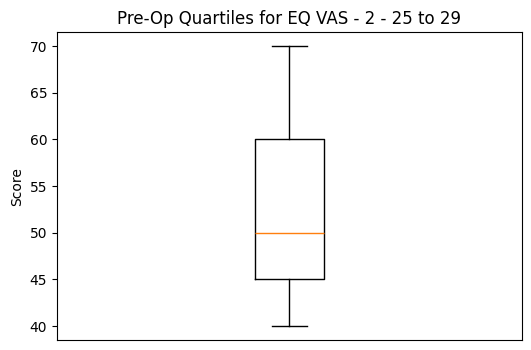

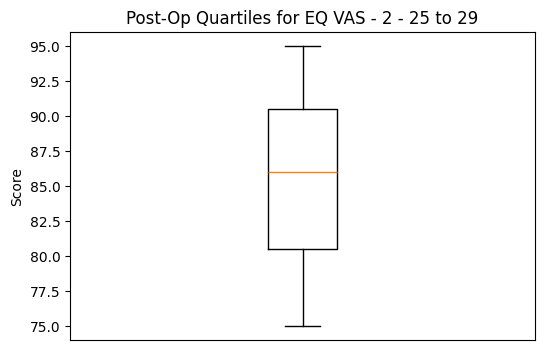

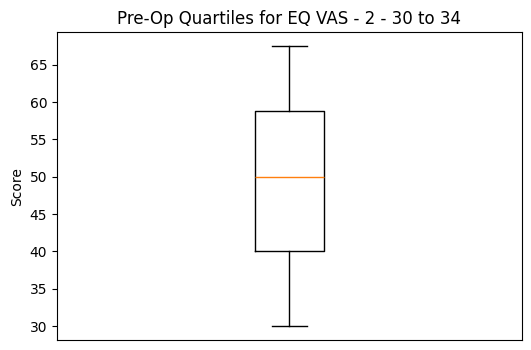

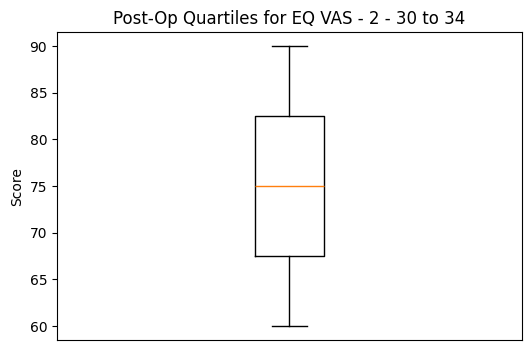

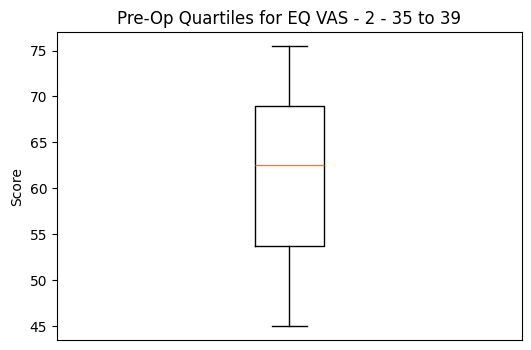

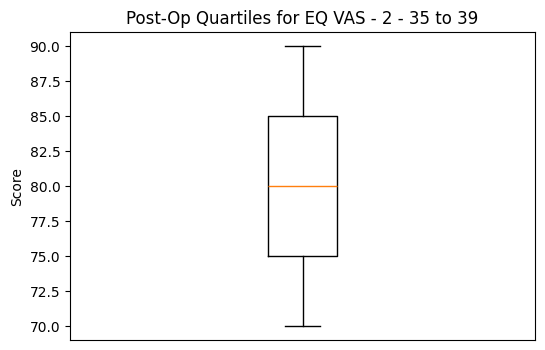

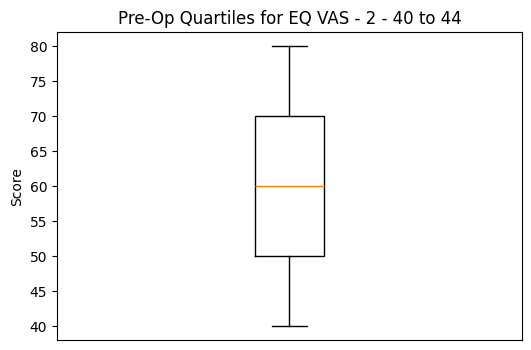

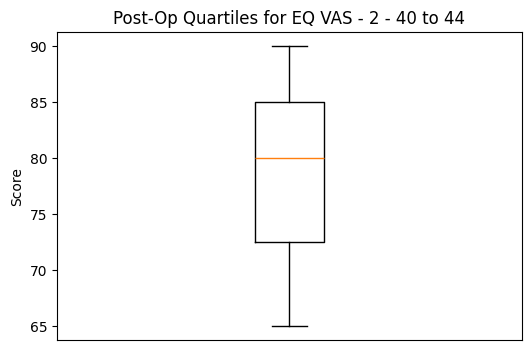

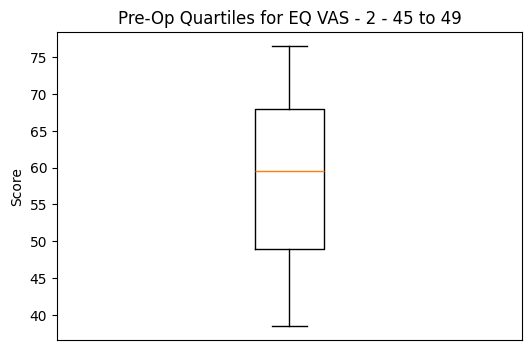

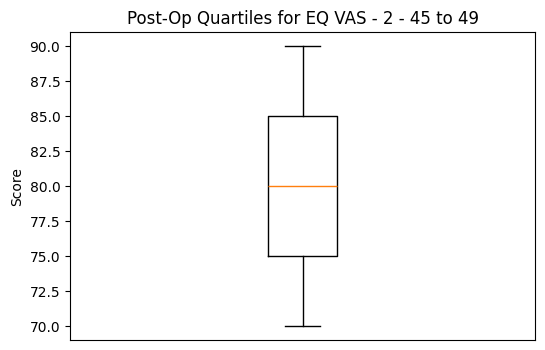

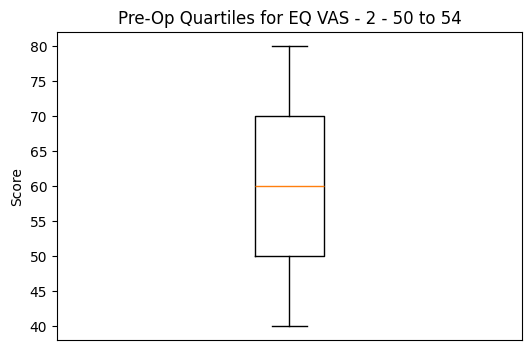

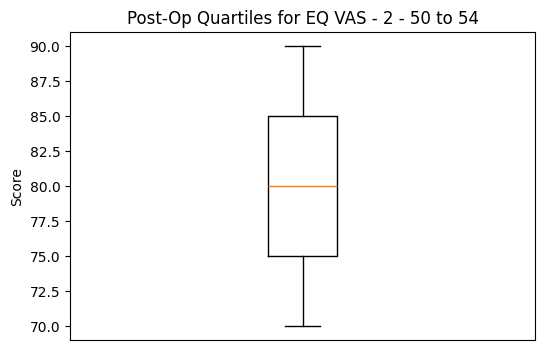

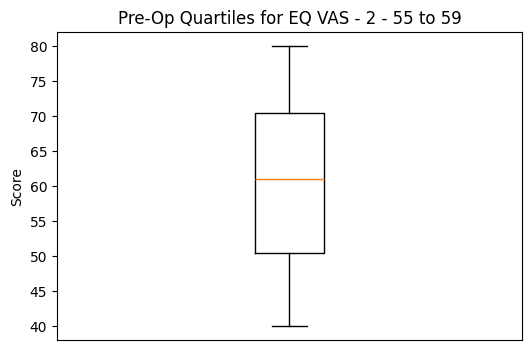

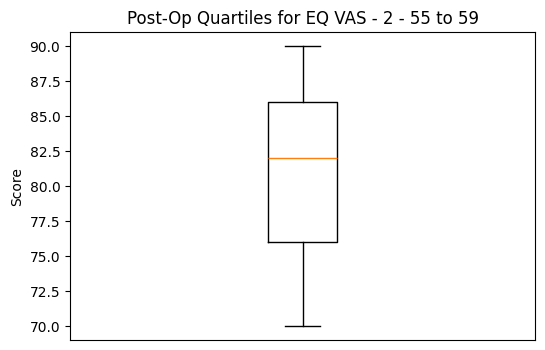

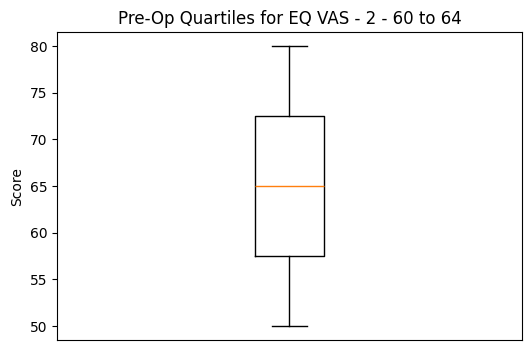

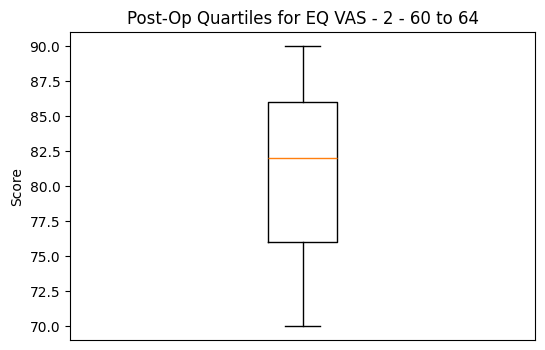

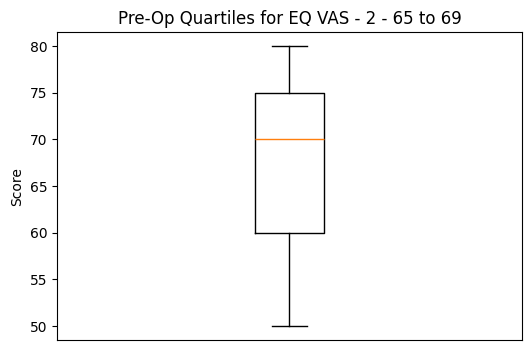

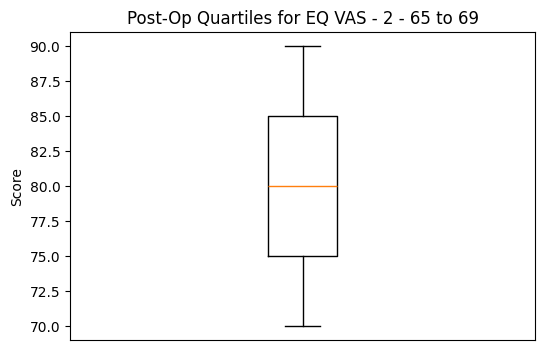

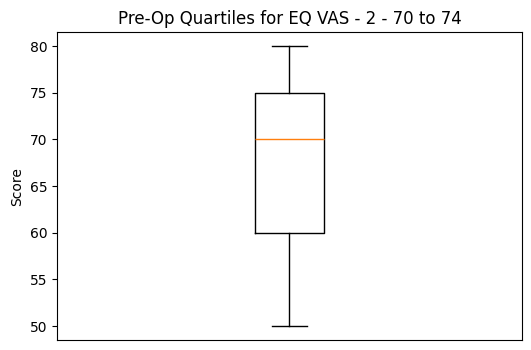

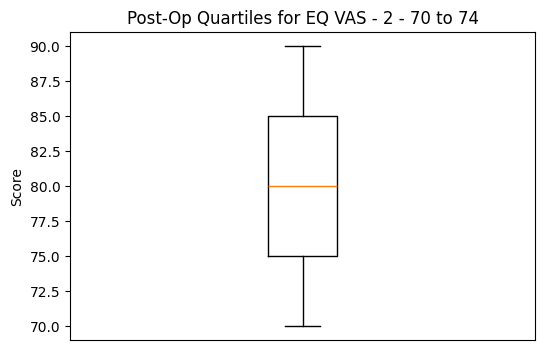

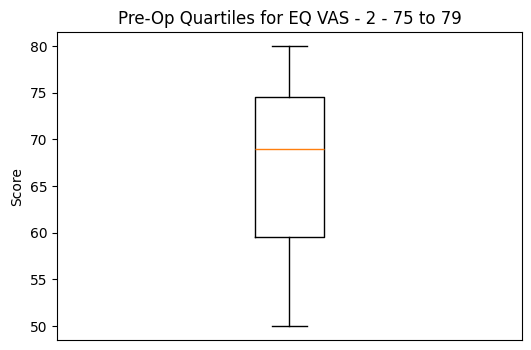

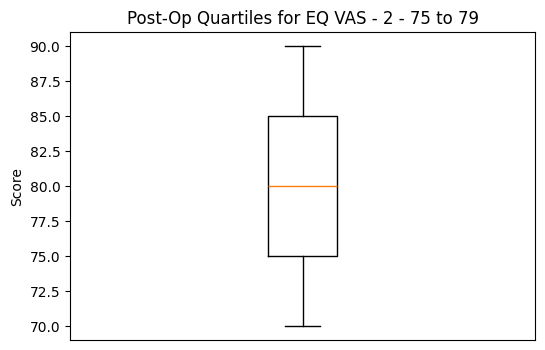

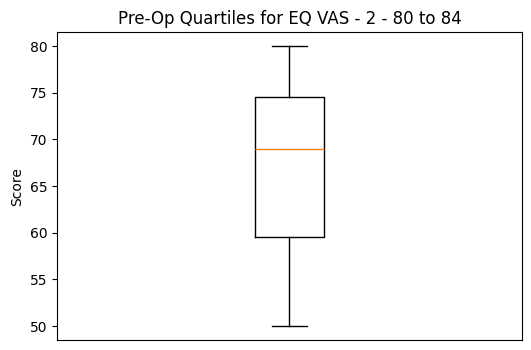

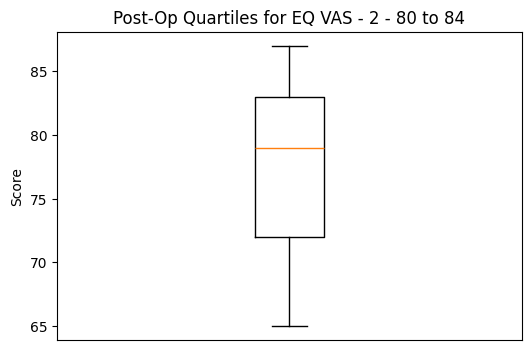

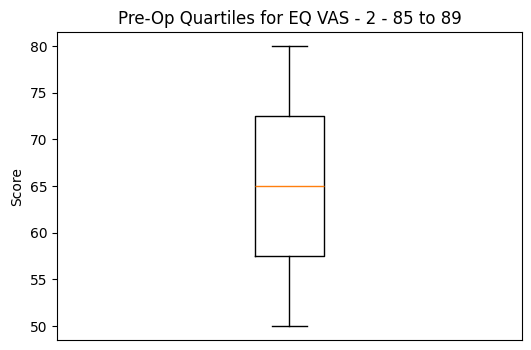

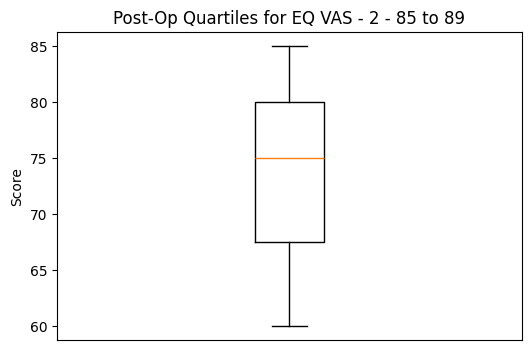

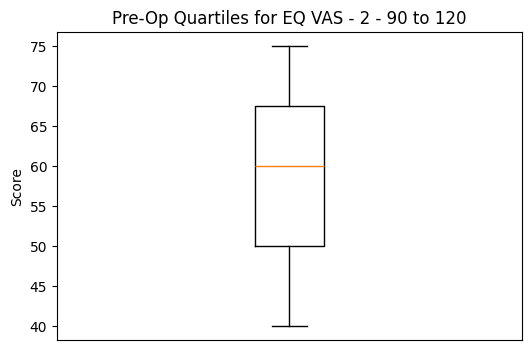

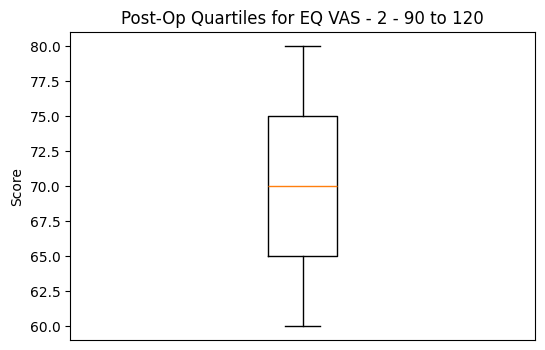

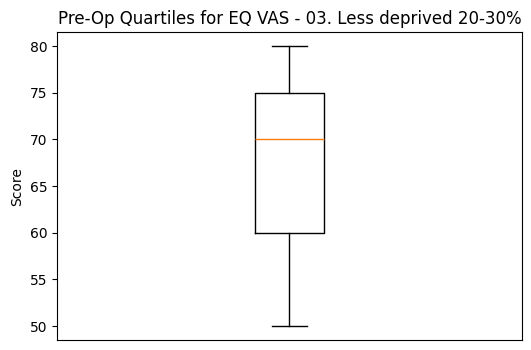

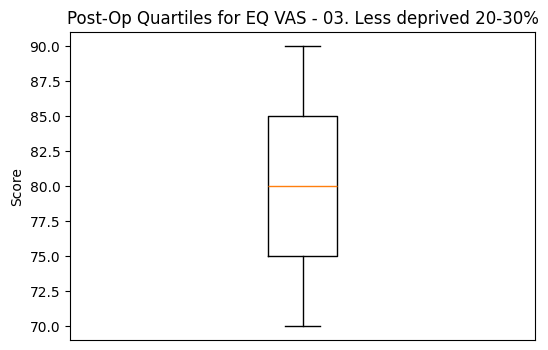

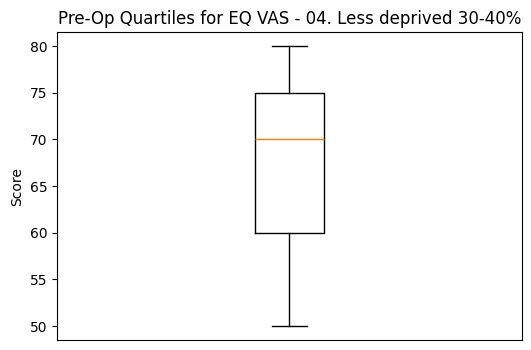

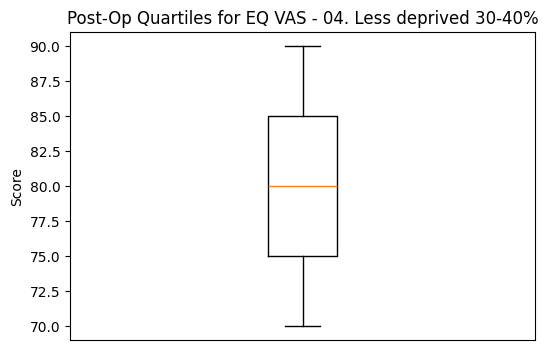

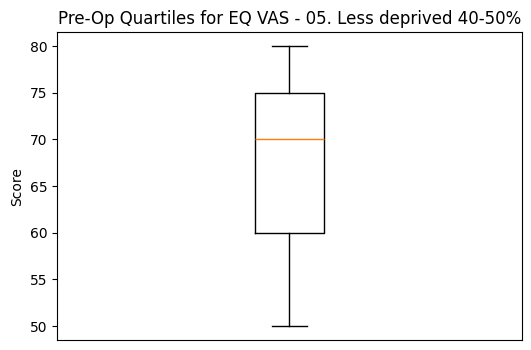

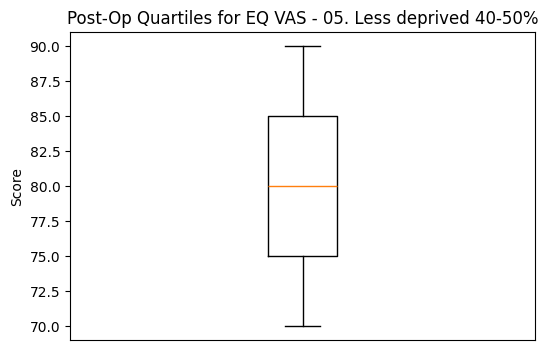

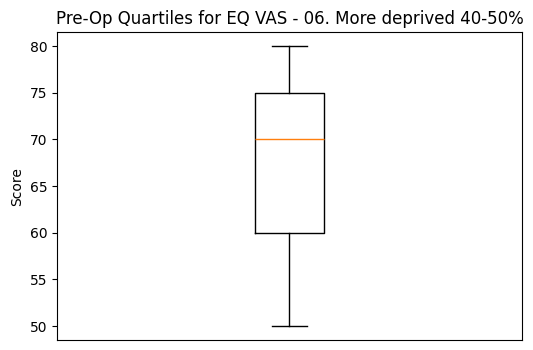

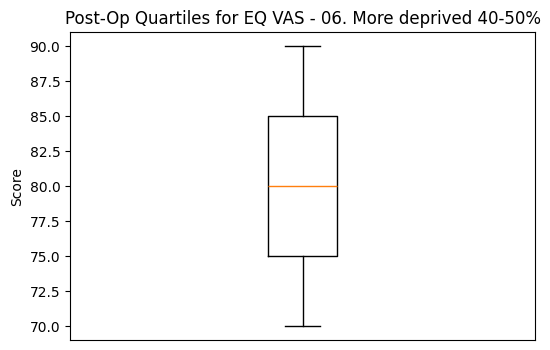

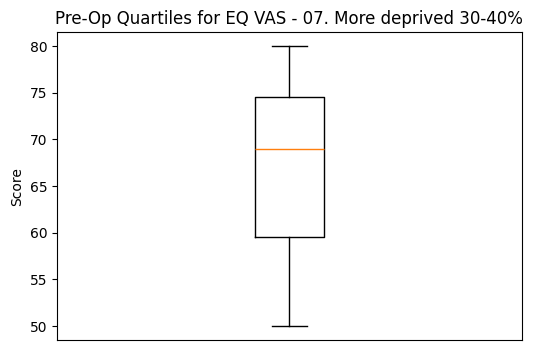

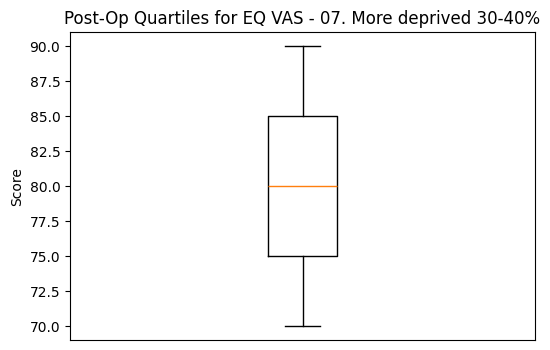

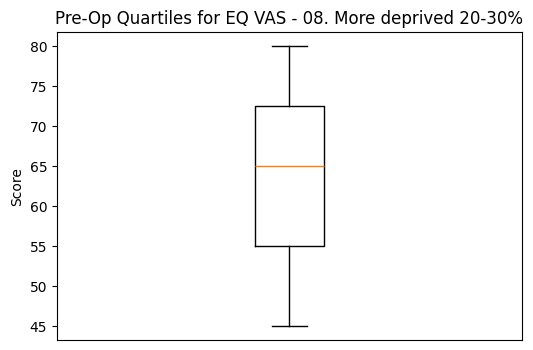

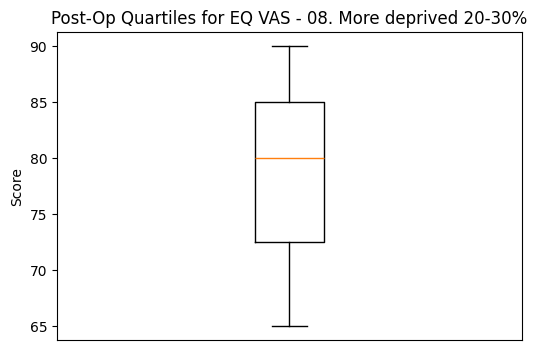

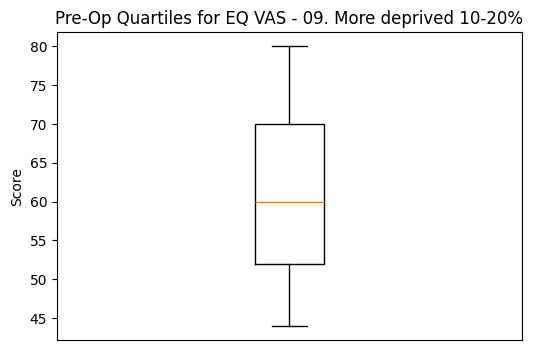

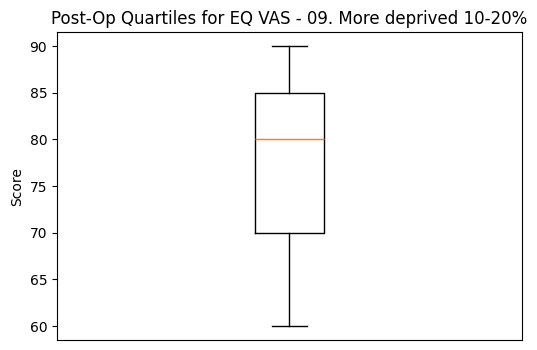

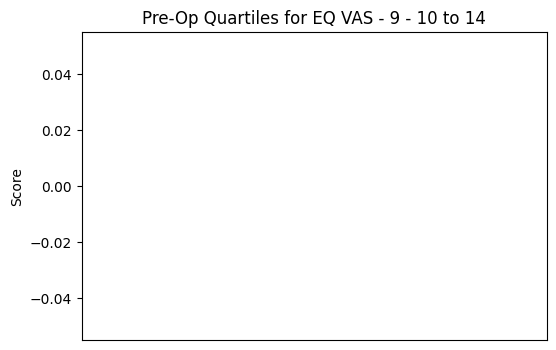

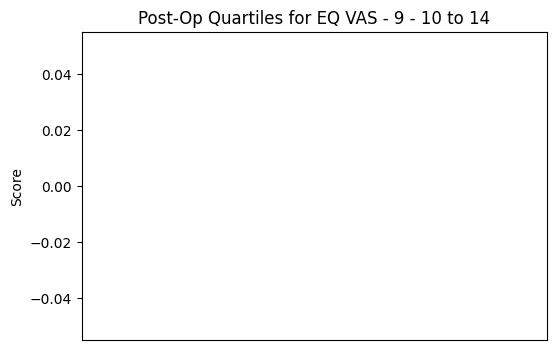

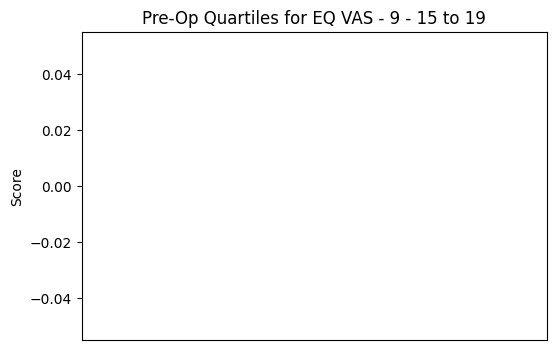

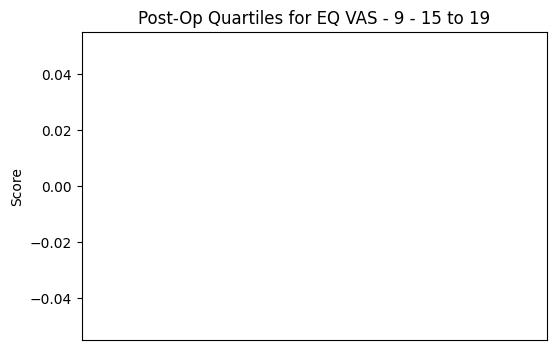

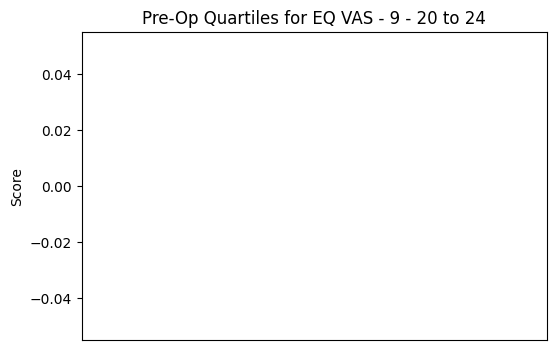

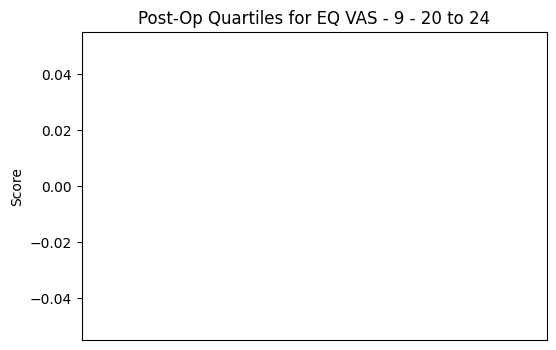

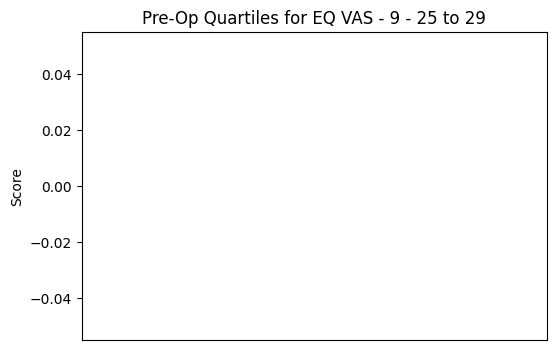

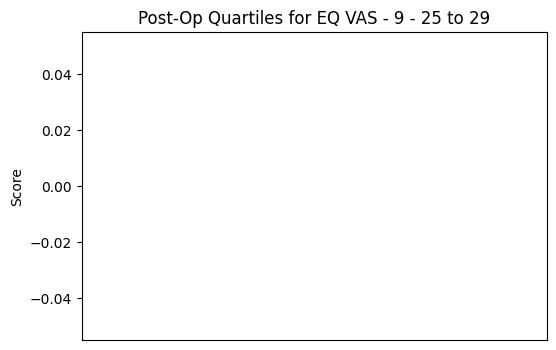

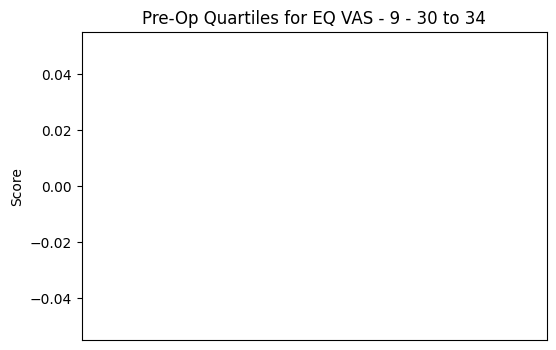

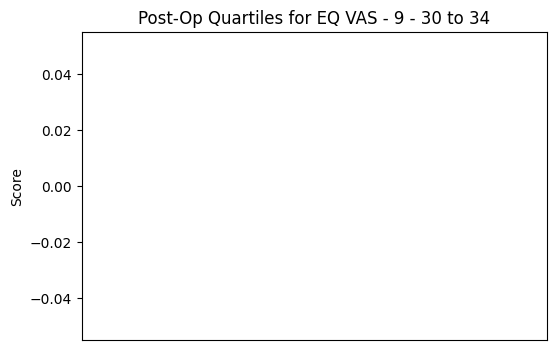

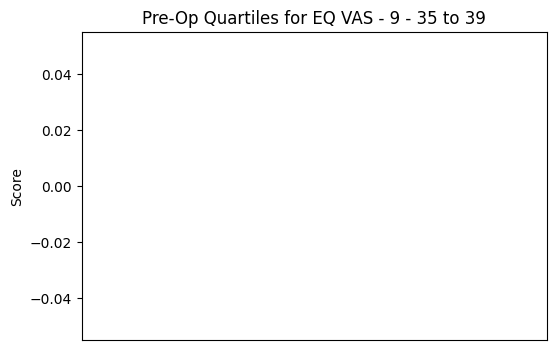

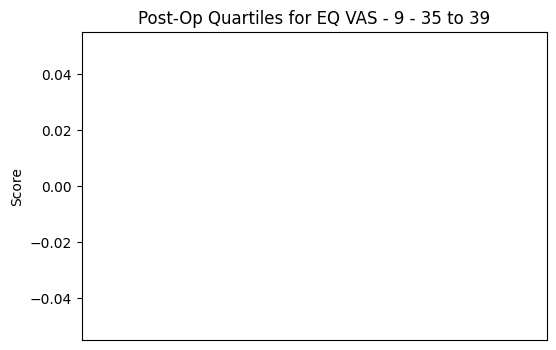

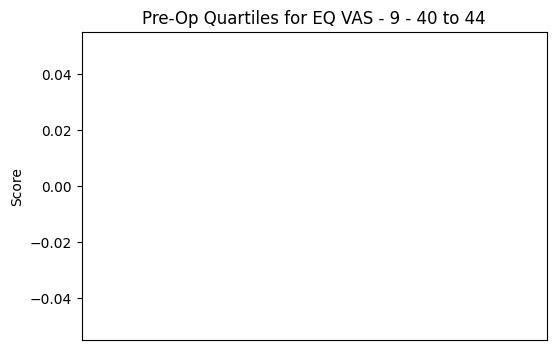

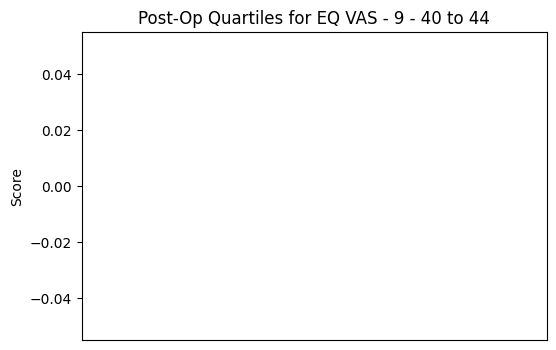

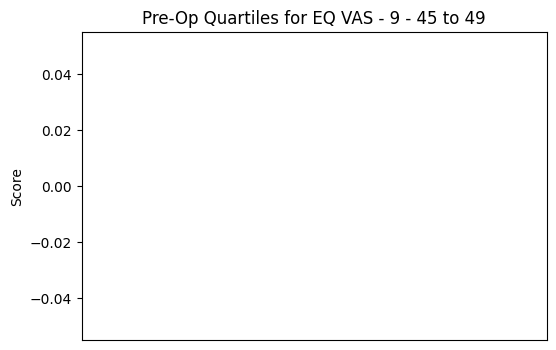

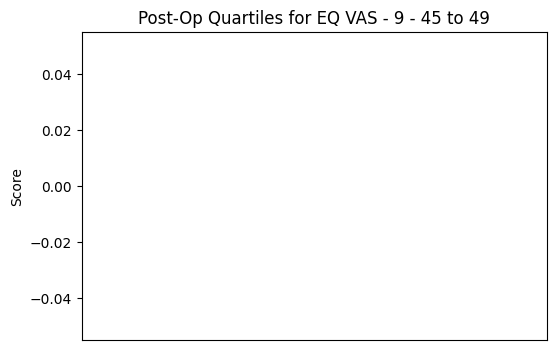

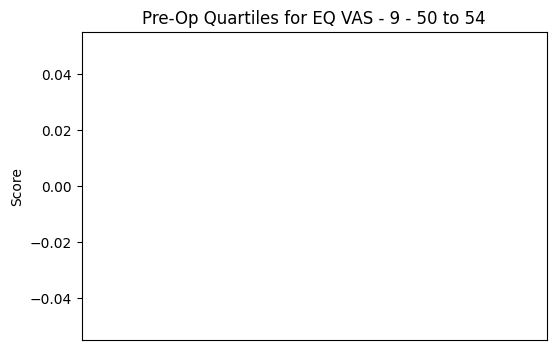

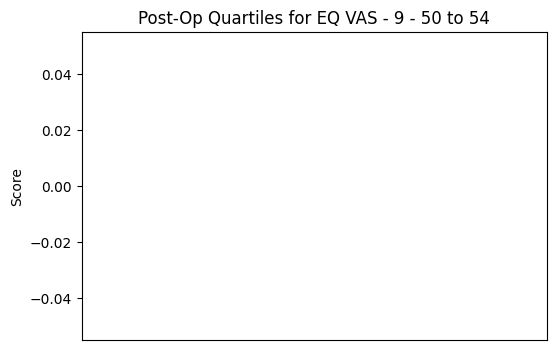

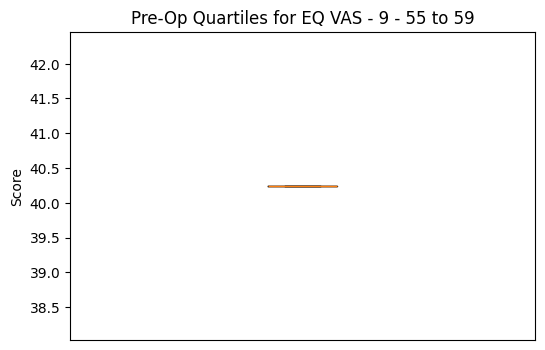

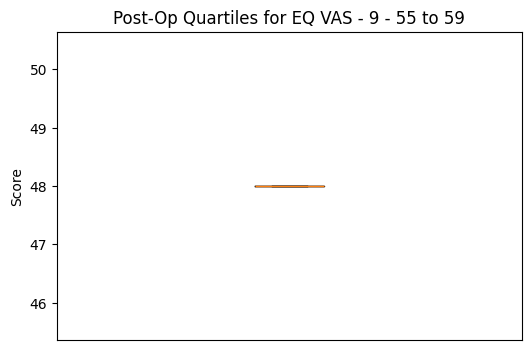

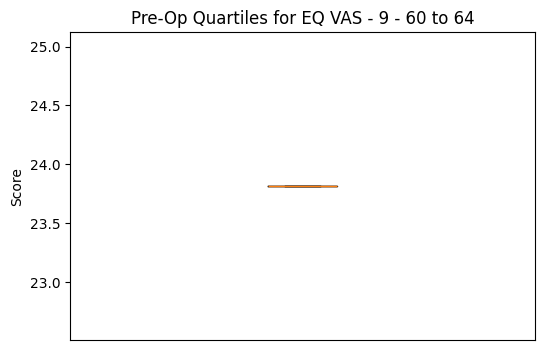

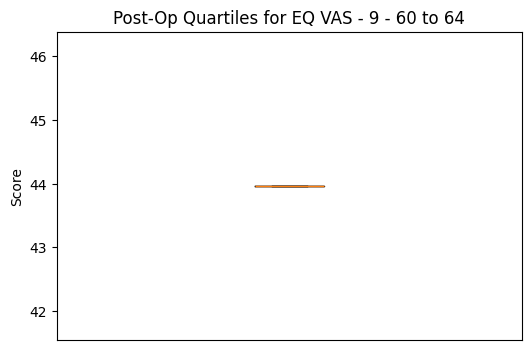

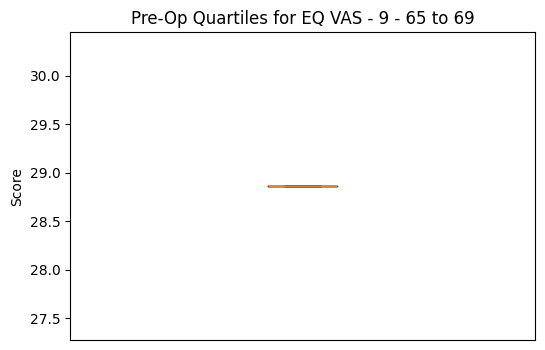

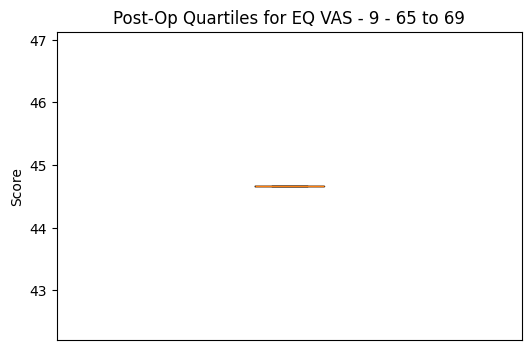

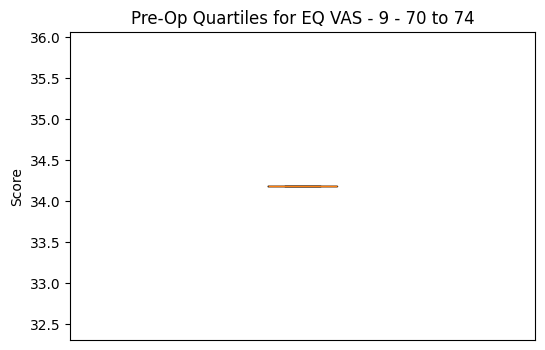

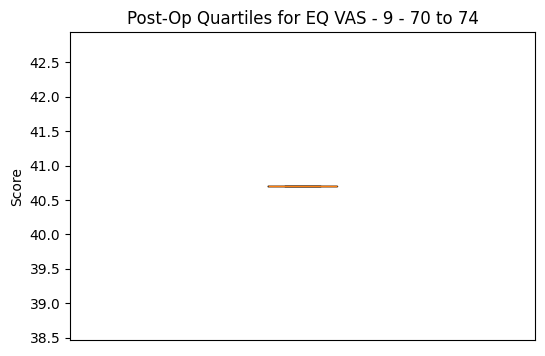

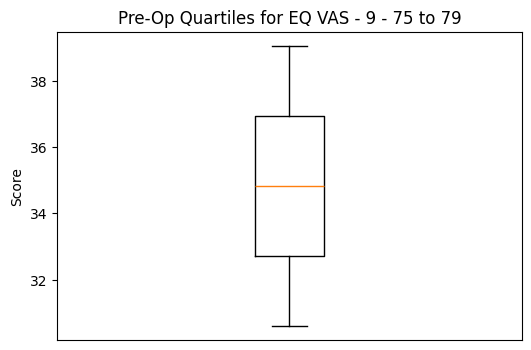

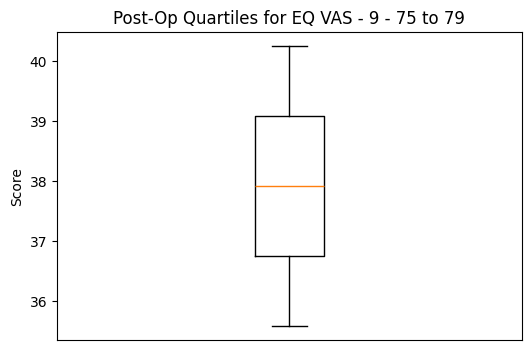

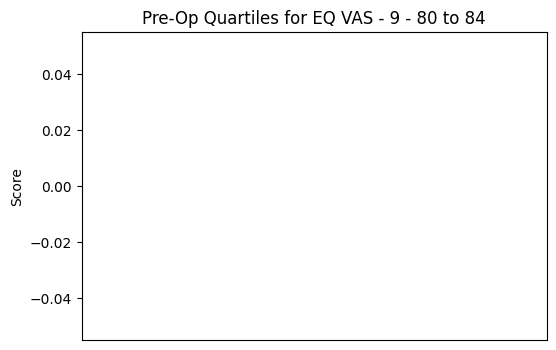

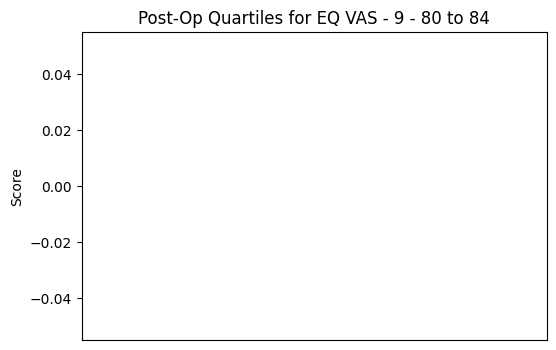

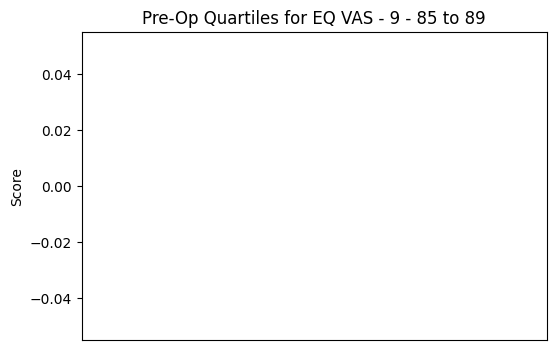

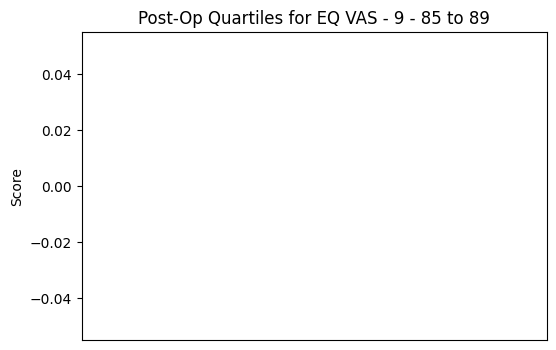

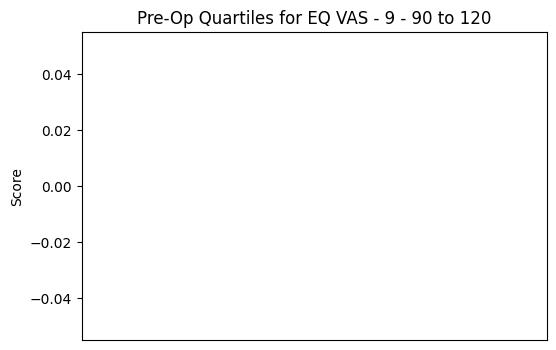

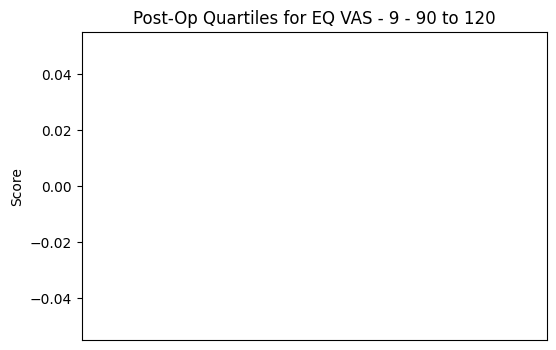

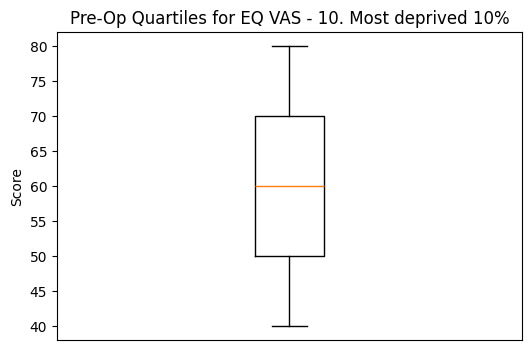

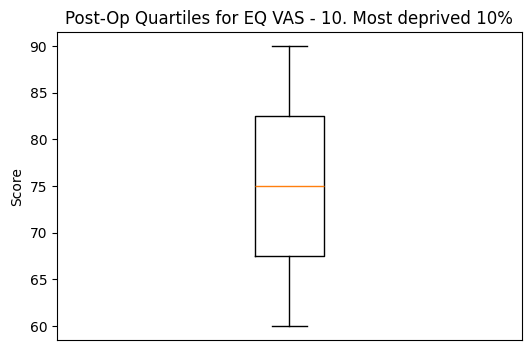

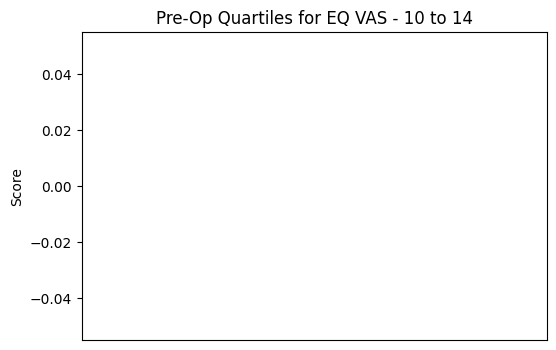

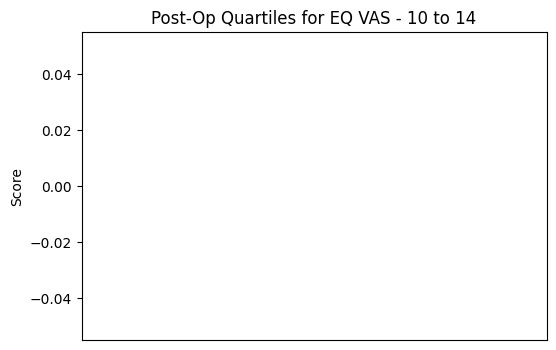

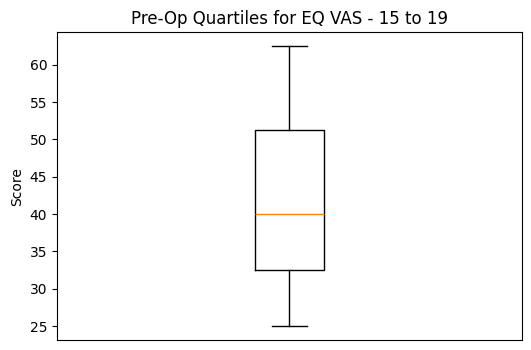

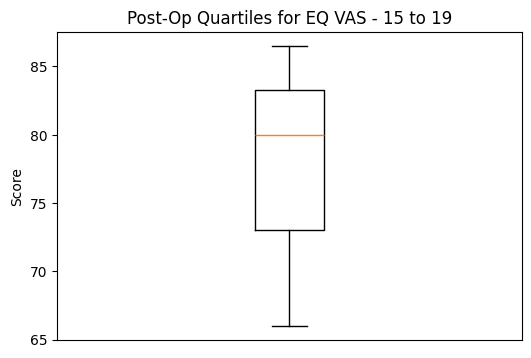

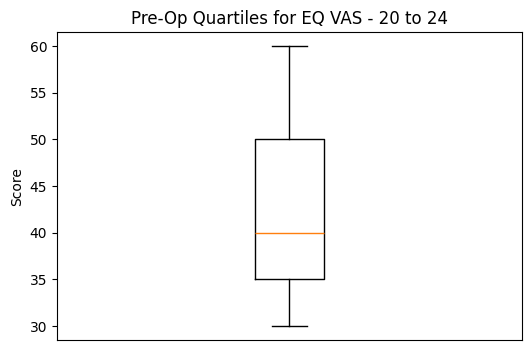

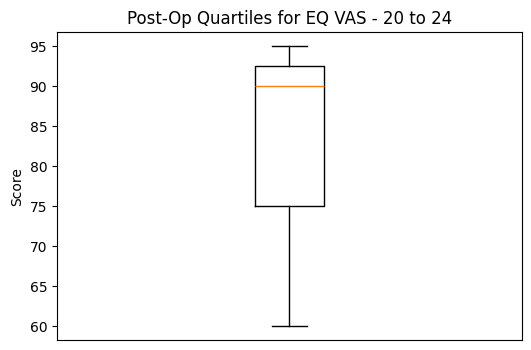

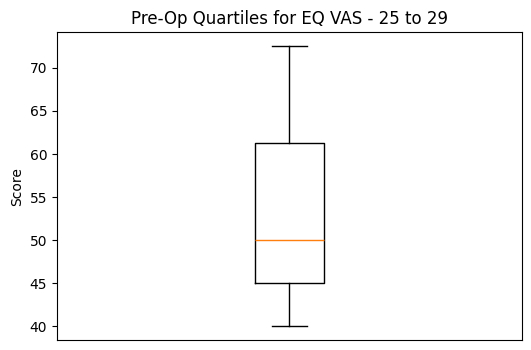

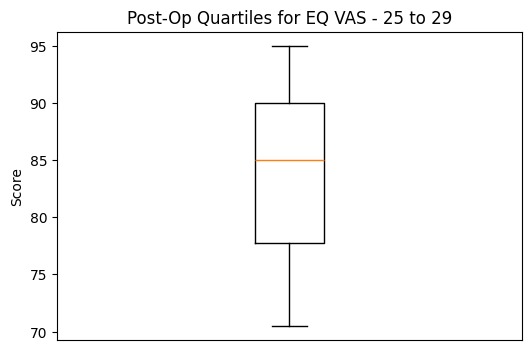

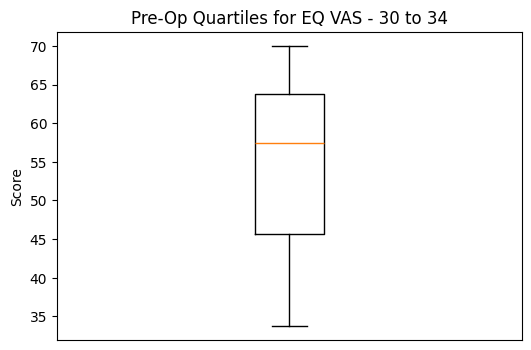

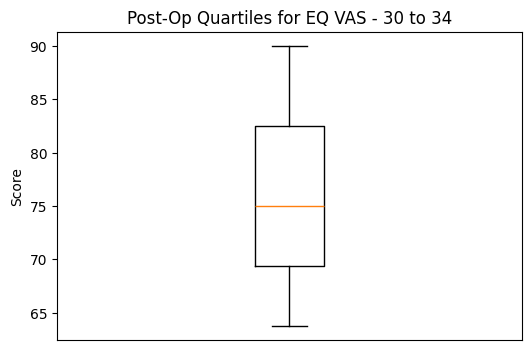

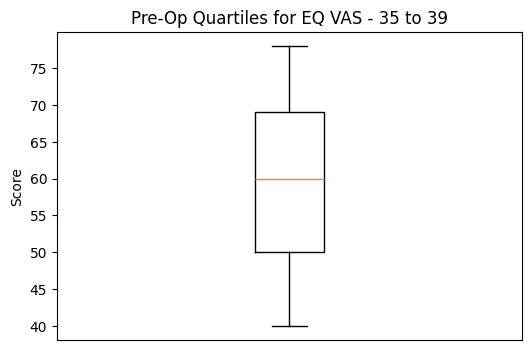

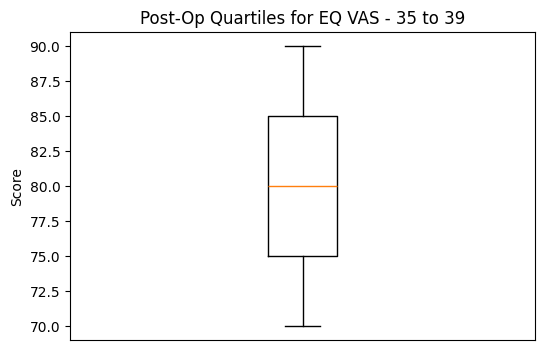

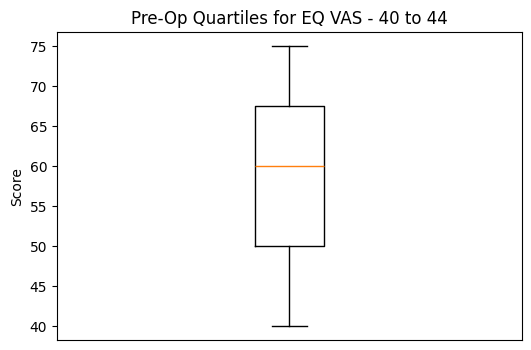

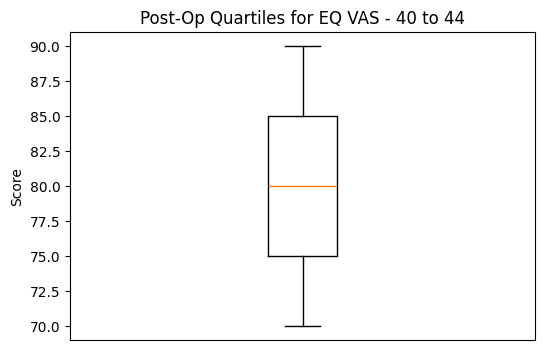

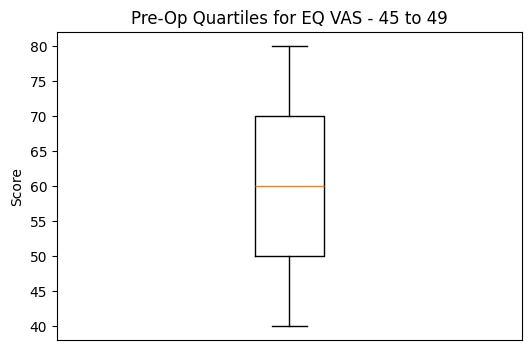

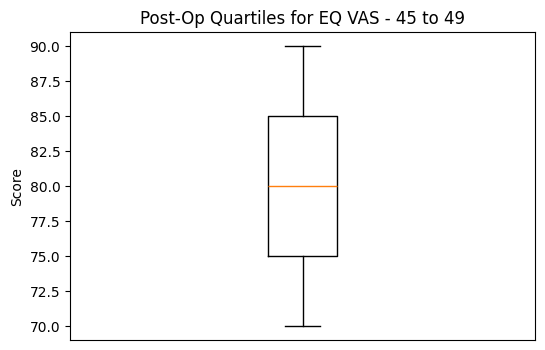

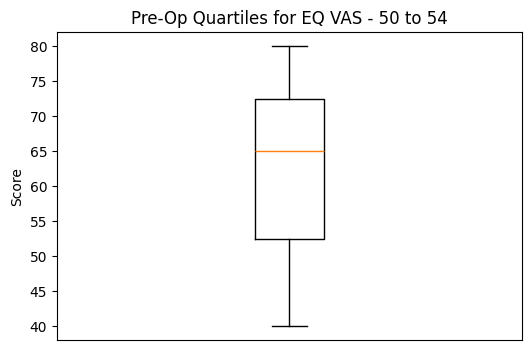

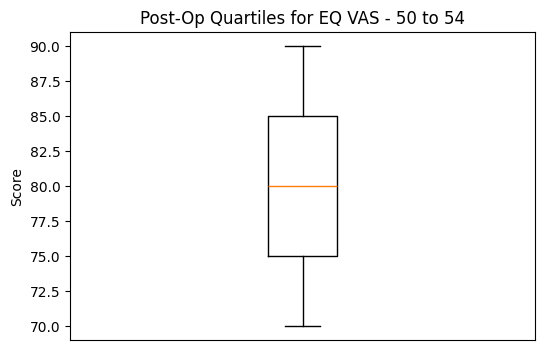

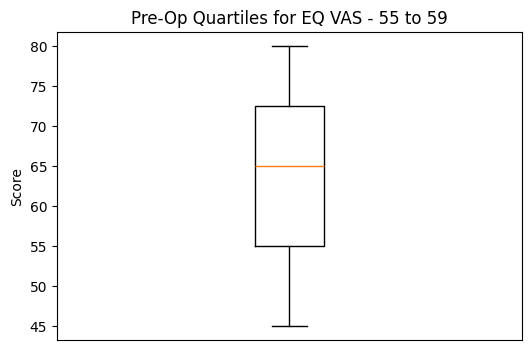

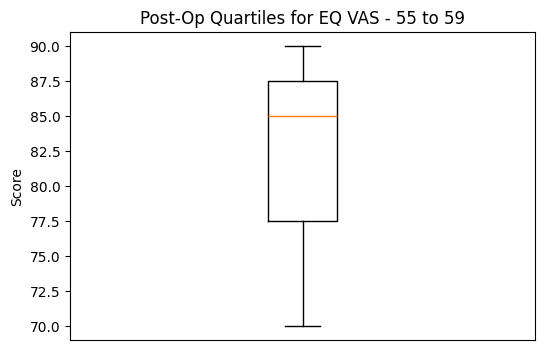

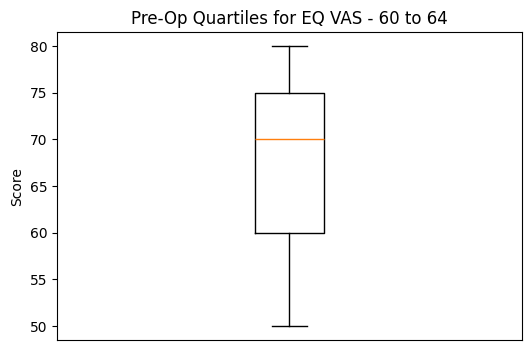

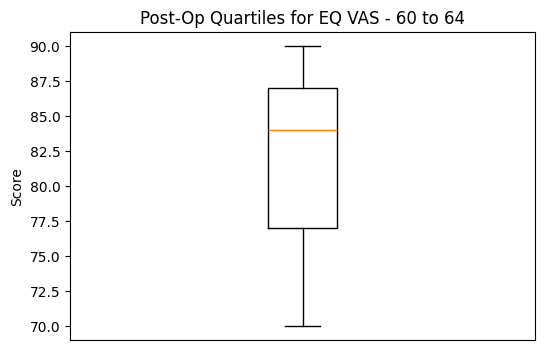

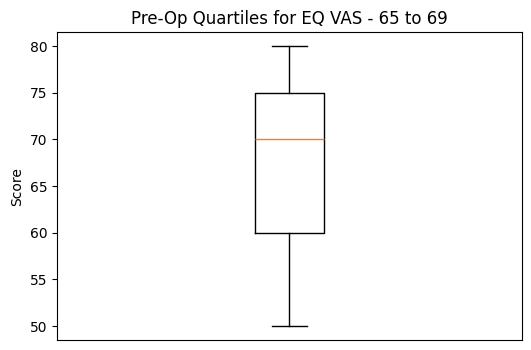

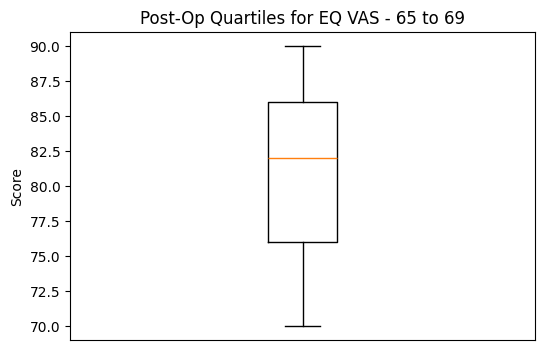

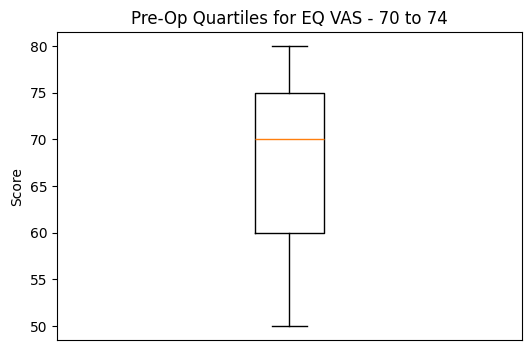

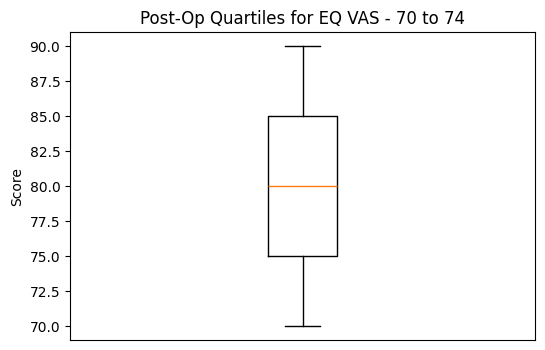

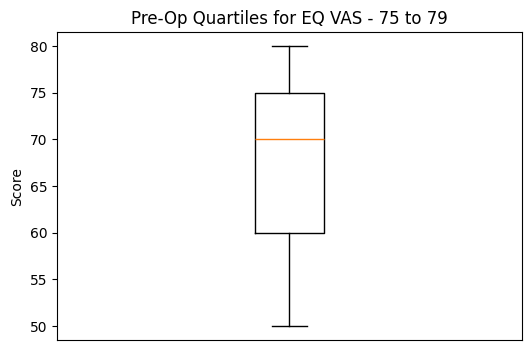

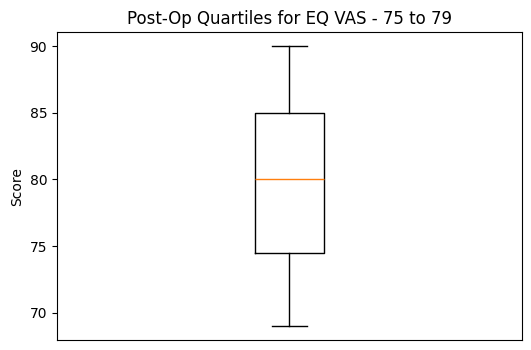

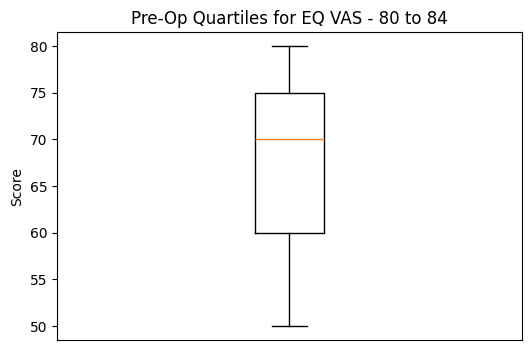

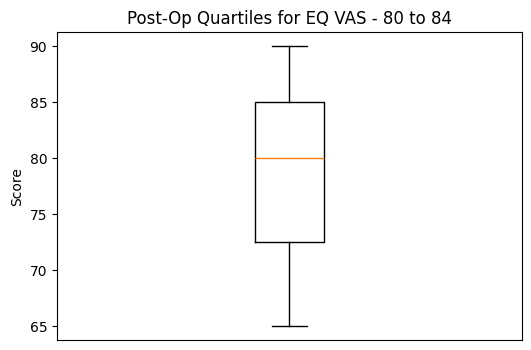

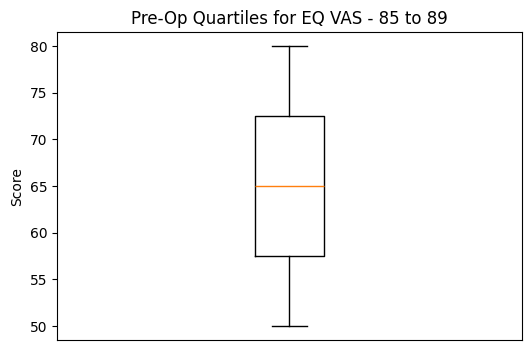

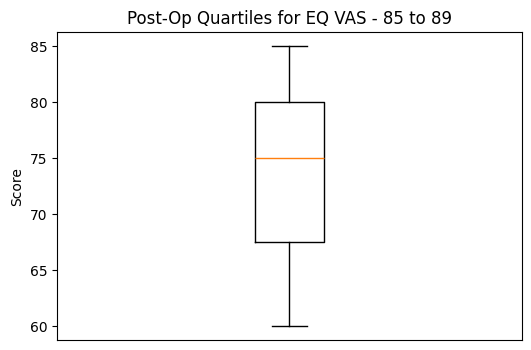

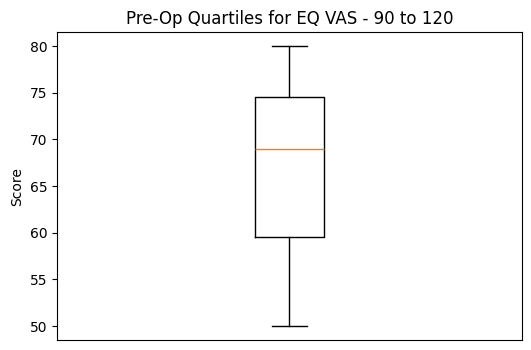

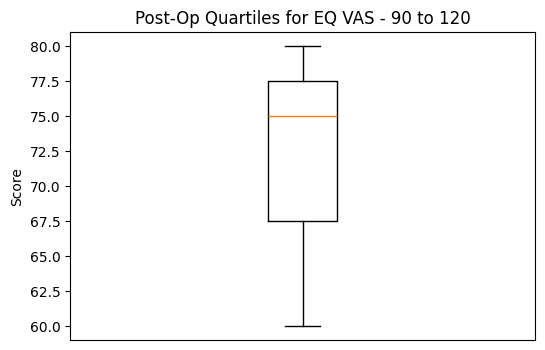

In [9]:
import matplotlib.pyplot as plt
import re

# Filter data for Hip Replacement and EQ VAS
data = merged_df[(merged_df['Procedure'] == 'Hip Replacement') & (merged_df['Measure'] == 'EQ VAS')]

# Function to sort Value
def sort_value(v):
    v = v.replace('Age and Gender,', '').strip()
    nums = re.findall(r'\d+', v)
    if len(nums) >= 2:
        return int(nums[0]), int(nums[1])
    return (0, 0)

data = data.copy()
data['Value_sort'] = data['Value'].apply(sort_value)
data = data.sort_values('Value_sort')
values = data['Value'].unique()

# Create separate graphs for each value type
for val in values:
    row = data[data['Value'] == val]
    if not row.empty:
        # Pre-op quartile graph for this value type
        fig, ax = plt.subplots(figsize=(6, 4))
        q1 = row['Pre-Op Q 1st Quartile'].values[0]
        med = row['Pre-Op Q Median'].values[0]
        q3 = row['Pre-Op Q 3rd Quartile'].values[0]
        ax.boxplot([[q1, med, q3]], positions=[1])
        ax.set_title(f'Pre-Op Quartiles for EQ VAS - {val}')
        ax.set_ylabel('Score')
        ax.set_xticks([])
        plt.show()

        # Post-op quartile graph for this value type
        fig, ax = plt.subplots(figsize=(6, 4))
        q1 = row['Post-Op Q 1st Quartile'].values[0]
        med = row['Post-Op Q Median'].values[0]
        q3 = row['Post-Op Q 3rd Quartile'].values[0]
        ax.boxplot([[q1, med, q3]], positions=[1])
        ax.set_title(f'Post-Op Quartiles for EQ VAS - {val}')
        ax.set_ylabel('Score')
        ax.set_xticks([])
        plt.show()

In [10]:
# Analyze groups with very less improvement
# Group by Value and compute average health gain and improvement rate
improvement_analysis = merged_df.groupby('Value').agg({
    'Heath Gain Mean': 'mean',
    'Improved': 'sum',
    'Total': 'sum'
})
improvement_analysis['Improvement Rate'] = improvement_analysis['Improved'] / improvement_analysis['Total']

# Sort by lowest health gain mean
least_improved_health_gain = improvement_analysis.sort_values('Heath Gain Mean').head(10)
print("Groups with least health gain (lowest Heath Gain Mean):")
print(least_improved_health_gain[['Heath Gain Mean', 'Improvement Rate']])

# Sort by lowest improvement rate
least_improved_rate = improvement_analysis.sort_values('Improvement Rate').head(10)
print("\nGroups with least improvement rate (lowest Improved/Total):")
print(least_improved_rate[['Heath Gain Mean', 'Improvement Rate']])

Groups with least health gain (lowest Heath Gain Mean):
              Heath Gain Mean  Improvement Rate
Value                                          
9 - 75 to 79         3.094333          0.333333
0 - 70 to 74         5.734667          1.000000
9 - 70 to 74         6.517250          0.750000
2 - 20 to 24         6.652944          0.881119
20 to 24             6.790778          0.851852
1 - 25 to 29         7.106444          0.796610
9 - 55 to 59         7.757667          1.000000
R                    7.945611          0.761155
F                    8.268056          0.783784
J                    8.423444          0.770346

Groups with least improvement rate (lowest Improved/Total):
                       Heath Gain Mean  Improvement Rate
Value                                                   
9 - 75 to 79                  3.094333          0.333333
0 - 60 to 64                  9.333333          0.666667
9 - 70 to 74                  6.517250          0.750000
R                     